### Run over 5 inital states, 10 rng seeds each

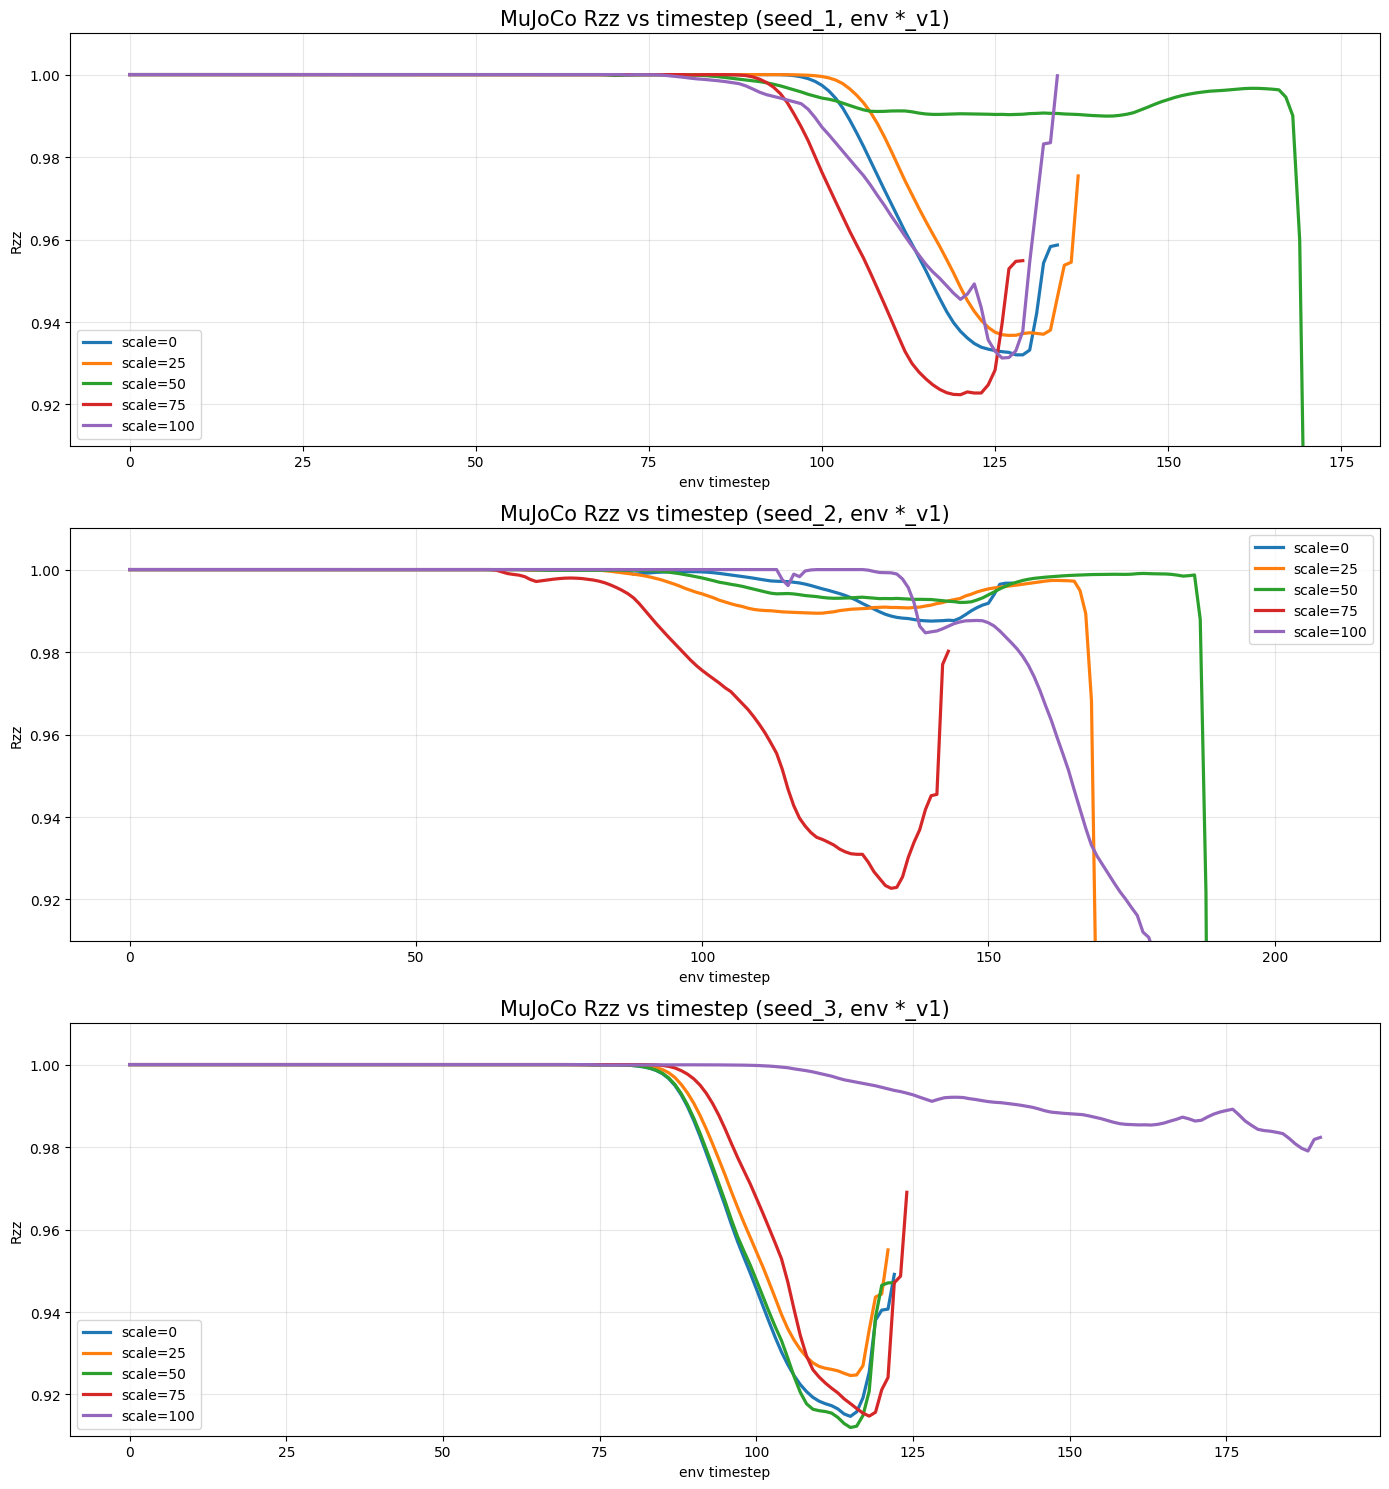

available seeds: [1, 2, 3]
missing seeds: []
seed 1: ['scale=0', 'scale=25', 'scale=50', 'scale=75', 'scale=100'] | init_name: n16h300r60g1bYfYv1
seed 2: ['scale=0', 'scale=25', 'scale=50', 'scale=75', 'scale=100'] | init_name: n16h300r60g1bYfYv1
seed 3: ['scale=0', 'scale=25', 'scale=50', 'scale=75', 'scale=100'] | init_name: n16h300r60g1bYfYv1
run root: /scratch/gilbreth/zoellner/diffusion_rollouts/can_rollouts/comparison/20260404_171101
Note: scale=10 is included only if dp_guidance_l10 exists in this run.


In [3]:
# Comparison to single seed tests of diffusion_guidance.ipynb

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# --- Config: same env used in guidance/diffusion_guidance.ipynb ---
RUN_ROOT_REL = Path("outputs/can_rollouts/comparison/20260404_171101")
TARGET_SEEDS = [1, 2, 3]
TARGET_INIT_NAME = "n16h300r60g1bYfYv1"  # exact env init from diffusion_guidance.ipynb
TARGET_INIT_SUFFIX = "v1"

# Map method folder -> guidance scale label for plotting
METHOD_SCALE_MAP = {
    "dp_base": 0,
    "dp_guidance_l10": 10,   # optional (not present in current comparison run)
    "dp_guidance_l25": 25,
    "dp_guidance_l50": 50,
    "dp_guidance_l75": 75,
    "dp_guidance_l100": 100,
}


def _find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "outputs").exists() and (candidate / "experiments").exists():
            return candidate
    raise FileNotFoundError(f"Could not find repo root from: {start}")


def _read_rows(rows_path: Path):
    rows = []
    if not rows_path.exists():
        return rows
    with rows_path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return rows


def _load_seed_series(run_root: Path, repo_root: Path, seed: int):
    series = []
    for method_slug, scale in sorted(METHOD_SCALE_MAP.items(), key=lambda kv: kv[1]):
        rows_path = run_root / method_slug / "rollout_rows.jsonl"
        rows = _read_rows(rows_path)
        if not rows:
            continue

        # Match seed + exact init first, then fallback to *_v1 suffix.
        candidates = [
            r for r in rows
            if int(r.get("seed", -1)) == seed
            and str(r.get("init_name", "")) == TARGET_INIT_NAME
        ]
        if not candidates:
            candidates = [
                r for r in rows
                if int(r.get("seed", -1)) == seed
                and str(r.get("init_name", "")).endswith(TARGET_INIT_SUFFIX)
            ]

        if not candidates:
            continue

        row = candidates[0]
        combo_dir = Path(row["combo_dir"])
        if not combo_dir.is_absolute():
            combo_dir = (repo_root / combo_dir).resolve()

        npz_path = combo_dir / "rollout_numeric.npz"
        if not npz_path.exists():
            continue

        data = np.load(npz_path)
        if "rzz_mujoco" not in data.files:
            continue

        rzz = np.asarray(data["rzz_mujoco"], dtype=np.float32)
        series.append((scale, rzz, method_slug, row.get("init_name", "")))

    series.sort(key=lambda x: x[0])
    return series


repo_root = _find_repo_root(Path.cwd())
run_root = (repo_root / RUN_ROOT_REL).resolve()
if not run_root.exists():
    raise FileNotFoundError(f"Run root not found: {run_root}")

seed_to_series = {}
for seed in TARGET_SEEDS:
    seed_to_series[seed] = _load_seed_series(run_root, repo_root, seed)

available_seeds = [s for s in TARGET_SEEDS if seed_to_series[s]]
missing_seeds = [s for s in TARGET_SEEDS if not seed_to_series[s]]
if not available_seeds:
    raise RuntimeError("No matching rollouts found for requested seed/env filter.")

# Use shared y-axis limits for easier cross-seed comparison.
all_rzz = np.concatenate([rzz for s in available_seeds for _, rzz, _, _ in seed_to_series[s]])
y_min = float(all_rzz.min()) - 0.002
y_max = float(all_rzz.max()) + 0.002

fig, axes = plt.subplots(
    nrows=len(available_seeds),
    ncols=1,
    figsize=(14, 5 * len(available_seeds)),
    sharey=True,
)
if len(available_seeds) == 1:
    axes = [axes]

for ax, seed in zip(axes, available_seeds):
    series = seed_to_series[seed]
    for scale, rzz, method_slug, init_name in series:
        ax.plot(np.arange(len(rzz)), rzz, linewidth=2.3, label=f"scale={scale}")

    ax.set_title(f"MuJoCo Rzz vs timestep (seed_{seed}, env *_v1)", fontsize=15)
    ax.set_xlabel("env timestep")
    ax.set_ylabel("Rzz")
    ax.set_ylim(0.91, 1.01)
    ax.grid(alpha=0.30)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print("available seeds:", available_seeds)
print("missing seeds:", missing_seeds)
for seed in available_seeds:
    scales = [f"scale={s}" for s, *_ in seed_to_series[seed]]
    init_name = seed_to_series[seed][0][3]
    print(f"seed {seed}:", scales, "| init_name:", init_name)

print("run root:", run_root)
print("Note: scale=10 is included only if dp_guidance_l10 exists in this run.")

In [ ]:
# Result table per method and overall

import json
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# --- Reload config and helper functions ---
RUN_ROOT_REL = Path("outputs/can_rollouts/comparison/20260404_171101")
TARGET_INIT_SUFFIX = "v1"

METHOD_SCALE_MAP = {
    "dp_base": 0,
    "dp_guidance_l10": 10,
    "dp_guidance_l25": 25,
    "dp_guidance_l50": 50,
    "dp_guidance_l75": 75,
    "dp_guidance_l100": 100,
    "snr_k8": "snr_k8",  # sample-and-rank
}

METHOD_LABELS = {
    "dp_base": "DP Base",
    "dp_guidance_l10": "DP Guidance (λ=10)",
    "dp_guidance_l25": "DP Guidance (λ=25)",
    "dp_guidance_l50": "DP Guidance (λ=50)",
    "dp_guidance_l75": "DP Guidance (λ=75)",
    "dp_guidance_l100": "DP Guidance (λ=100)",
    "snr_k8": "Sample-and-Rank (k=8)",
}

def _find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "outputs").exists() and (candidate / "experiments").exists():
            return candidate
    raise FileNotFoundError(f"Could not find repo root from: {start}")


def _read_rows(rows_path: Path):
    rows = []
    if not rows_path.exists():
        return rows
    with rows_path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return rows


repo_root = _find_repo_root(Path.cwd())
run_root = (repo_root / RUN_ROOT_REL).resolve()

# Aggregate mean Rzz per method, overall and per environment
method_to_rzz_values = defaultdict(list)
method_to_env_rzz = defaultdict(lambda: defaultdict(list))

for method_slug in METHOD_SCALE_MAP.keys():
    rows_path = run_root / method_slug / "rollout_rows.jsonl"
    rows = _read_rows(rows_path)
    
    for row in rows:
        init_name = str(row.get("init_name", ""))
        if not init_name.endswith(TARGET_INIT_SUFFIX):
            continue
        
        mean_rzz = float(row.get("mean_rzz", np.nan))
        if not np.isnan(mean_rzz):
            method_to_rzz_values[method_slug].append(mean_rzz)
            method_to_env_rzz[method_slug][init_name].append(mean_rzz)

# Compute overall averages per method
overall_results = []
for method_slug, rzz_list in sorted(method_to_rzz_values.items()):
    if not rzz_list:
        continue
    mean = np.mean(rzz_list)
    std = np.std(rzz_list)
    count = len(rzz_list)
    label = METHOD_LABELS.get(method_slug, method_slug)
    overall_results.append({
        "slug": method_slug,
        "label": label,
        "mean": mean,
        "std": std,
        "count": count,
    })

# Sort by mean descending (best first)
overall_results.sort(key=lambda x: x["mean"], reverse=True)

print("=" * 90)
print("OVERALL MEAN RZZ ACROSS ALL SEEDS & ENVIRONMENTS")
print("=" * 90)
print(f"{'Method':<35} {'Mean Rzz':>12} {'Std Dev':>12} {'N':>6}")
print("-" * 90)
for r in overall_results:
    print(f"{r['label']:<35} {r['mean']:>12.6f} {r['std']:>12.6f} {r['count']:>6}")
print()

# Per-environment breakdown
print("=" * 90)
print("PER-ENVIRONMENT MEAN RZZ")
print("=" * 90)

all_envs = set()
for method_data in method_to_env_rzz.values():
    all_envs.update(method_data.keys())

for env_name in sorted(all_envs):
    print(f"\n--- Environment: {env_name} ---")
    env_results = []
    for method_slug in sorted(method_to_env_rzz.keys()):
        rzz_list = method_to_env_rzz[method_slug].get(env_name, [])
        if not rzz_list:
            continue
        mean = np.mean(rzz_list)
        count = len(rzz_list)
        label = METHOD_LABELS.get(method_slug, method_slug)
        env_results.append({
            "label": label,
            "mean": mean,
            "count": count,
        })
    
    if env_results:
        env_results.sort(key=lambda x: x["mean"], reverse=True)
        print(f"{'Method':<35} {'Mean Rzz':>12} {'N':>6}")
        print("-" * 55)
        for r in env_results:
            print(f"{r['label']:<35} {r['mean']:>12.6f} {r['count']:>6}")
    else:
        print("  (no data)")

# Quick visualization: bar chart of overall means
fig, ax = plt.subplots(figsize=(12, 6))
methods = [r["label"] for r in overall_results]
means = [r["mean"] for r in overall_results]
stds = [r["std"] for r in overall_results]

colors = plt.cm.Set2(np.linspace(0, 1, len(methods)))
bars = ax.bar(range(len(methods)), means, yerr=stds, capsize=5, color=colors, alpha=0.75)

ax.set_ylabel("Mean Rzz (across all seeds & envs)", fontsize=12)
ax.set_title("Overall Mean Rzz by Method", fontsize=14)
ax.set_xticks(range(len(methods)))
ax.set_xticklabels(methods, rotation=45, ha="right")
ax.set_ylim([0.9, 1.0])
ax.grid(axis="y", alpha=0.3)

for i, (mean, std) in enumerate(zip(means, stds)):
    ax.text(i, mean + std + 0.002, f"{mean:.4f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

print("\n✓ Analysis complete.")


import json
from pathlib import Path

import numpy as np

# =========================
# ALL-ENV AGGREGATION TABLE
# =========================
# Constraint violation definitions used here:
#   timestep_violation_pct = 100 * mean(rzz_mujoco < RZZ_THRESHOLD)
#   trajectory_violation_pct = 100 * mean(any timestep in rollout is below RZZ_THRESHOLD)

RUN_ROOT_REL = Path("outputs/can_rollouts/comparison/20260404_171101")
RZZ_THRESHOLD = 0.98

TARGET_ENVS = [
    "n16h300r60g1bYfYv1",
    "n16h300r60g1bYfYv3",
    "n16h300r60g1bYfYv4",
    "n16h300r60g1bYfYv5",
    "n8h300r30g1bYfY",
]

METHOD_ORDER = [
    "dp_base",
    "snr_k8",
    "dp_guidance_l25",
    "dp_guidance_l50",
    "dp_guidance_l75",
    "dp_guidance_l100",
]

METHOD_LABELS = {
    "dp_base": "DP Base",
    "snr_k8": "Sample-and-Rank (k=8)",
    "dp_guidance_l25": "Guidance λ=25",
    "dp_guidance_l50": "Guidance λ=50",
    "dp_guidance_l75": "Guidance λ=75",
    "dp_guidance_l100": "Guidance λ=100",
}


def _find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "outputs").exists() and (candidate / "experiments").exists():
            return candidate
    raise FileNotFoundError(f"Could not find repo root from: {start}")


def _read_rows(path: Path):
    rows = []
    if not path.exists():
        return rows
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def _resolve_run_root(repo_root: Path, rel_path: Path) -> Path:
    candidate = (repo_root / rel_path).resolve()
    if candidate.exists():
        return candidate

    alt = (Path("/scratch/gilbreth/zoellner/diffusion_rollouts") / rel_path).resolve()
    if alt.exists():
        return alt

    raise FileNotFoundError(f"Run root not found in either location:\n- {candidate}\n- {alt}")


def _violation_pct(npz_path: Path, threshold: float) -> float:
    data = np.load(npz_path)
    if "rzz_mujoco" not in data.files:
        return float("nan")
    rzz = np.asarray(data["rzz_mujoco"], dtype=np.float32)
    if len(rzz) == 0:
        return float("nan")
    return float(np.mean(rzz < threshold) * 100.0)


def _trajectory_violation_pct(npz_path: Path, threshold: float) -> float:
    data = np.load(npz_path)
    if "rzz_mujoco" not in data.files:
        return float("nan")
    rzz = np.asarray(data["rzz_mujoco"], dtype=np.float32)
    if len(rzz) == 0:
        return float("nan")
    return float(np.any(rzz < threshold) * 100.0)


def _format_table(rows, columns):
    widths = []
    for col in columns:
        max_cell = max([len(str(r.get(col, ""))) for r in rows], default=0)
        widths.append(max(len(col), max_cell))

    header = "  ".join(col.ljust(w) for col, w in zip(columns, widths))
    sep = "  ".join("-" * w for w in widths)
    lines = [header, sep]

    for r in rows:
        line = "  ".join(str(r.get(col, "")).ljust(w) for col, w in zip(columns, widths))
        lines.append(line)
    return "\n".join(lines)


repo_root = _find_repo_root(Path.cwd())
run_root = _resolve_run_root(repo_root, RUN_ROOT_REL)

records = []
for method_slug in METHOD_ORDER:
    rows_path = run_root / method_slug / "rollout_rows.jsonl"
    rows = _read_rows(rows_path)

    for row in rows:
        init_name = str(row.get("init_name", ""))
        if init_name not in TARGET_ENVS:
            continue

        seed = int(row.get("seed", -1))
        combo_dir = Path(row["combo_dir"])
        if not combo_dir.is_absolute():
            combo_dir = (repo_root / combo_dir).resolve()
        if not combo_dir.exists():
            combo_dir = (run_root / method_slug / f"{init_name}__seed_{seed:02d}").resolve()

        npz_path = combo_dir / "rollout_numeric.npz"
        if not npz_path.exists():
            continue

        records.append(
            {
                "method_slug": method_slug,
                "method_label": METHOD_LABELS.get(method_slug, method_slug),
                "env": init_name,
                "seed": seed,
                "mean_rzz": float(row.get("mean_rzz", np.nan)),
                "success": float(bool(row.get("success", False))),
                "timestep_violation_pct": _violation_pct(npz_path, RZZ_THRESHOLD),
                "trajectory_violation_pct": _trajectory_violation_pct(npz_path, RZZ_THRESHOLD),
            }
        )

if not records:
    raise RuntimeError("No records found for requested env list.")

expected = len(TARGET_ENVS) * 10 * len(METHOD_ORDER)
print(f"run root: {run_root}")
print(f"constraint threshold: rzz < {RZZ_THRESHOLD}")
print(f"records found: {len(records)} / expected approx: {expected}")


def _aggregate(subset):
    by_method = {}
    for method_slug in METHOD_ORDER:
        vals = [r for r in subset if r["method_slug"] == method_slug]
        if not vals:
            continue

        rzz_vals = np.asarray([v["mean_rzz"] for v in vals], dtype=np.float64)
        succ_vals = np.asarray([v["success"] for v in vals], dtype=np.float64) * 100.0
        timestep_vio_vals = np.asarray([v["timestep_violation_pct"] for v in vals], dtype=np.float64)
        traj_vio_vals = np.asarray([v["trajectory_violation_pct"] for v in vals], dtype=np.float64)

        by_method[method_slug] = {
            "method_slug": method_slug,
            "method_label": METHOD_LABELS.get(method_slug, method_slug),
            "N": len(vals),
            "Avg_Rzz": float(np.mean(rzz_vals)),
            "Std_Rzz": float(np.std(rzz_vals)),
            "Avg_Success": float(np.mean(succ_vals)),
            "Std_Success": float(np.std(succ_vals)),
            "Timestep_Violation_%": float(np.mean(timestep_vio_vals)),
            "Std_Timestep_Violation": float(np.std(timestep_vio_vals)),
            "Trajectory_Violation_%": float(np.mean(traj_vio_vals)),
            "Std_Trajectory_Violation": float(np.std(traj_vio_vals)),
        }
    return by_method


overall = _aggregate(records)

guidance_slugs = [m for m in METHOD_ORDER if m.startswith("dp_guidance_l") and m in overall]
if not guidance_slugs:
    raise RuntimeError("No guidance methods found in records.")

best_guidance_slug = max(guidance_slugs, key=lambda m: overall[m]["Avg_Rzz"])
best_guidance_label = METHOD_LABELS[best_guidance_slug]

print(f"\nBest guidance scale by overall Avg_Rzz: {best_guidance_label}")

concise_methods = ["dp_base", "snr_k8", best_guidance_slug]


def _round_row(d):
    return {
        "Method": d["method_label"],
        "N": d["N"],
        "Avg_Rzz ± Std": f"{d['Avg_Rzz']:.6f} ± {d['Std_Rzz']:.6f}",
        "Avg_Success_% ± Std": f"{d['Avg_Success']:.2f} ± {d['Std_Success']:.2f}",
        "Timestep_Violation_% ± Std": f"{d['Timestep_Violation_%']:.2f} ± {d['Std_Timestep_Violation']:.2f}",
        "Trajectory_Violation_% ± Std": f"{d['Trajectory_Violation_%']:.2f} ± {d['Std_Trajectory_Violation']:.2f}",
    }


table_cols = [
    "Method",
    "N",
    "Avg_Rzz ± Std",
    "Avg_Success_% ± Std",
    "Timestep_Violation_% ± Std",
    "Trajectory_Violation_% ± Std",
]

print("\n" + "=" * 110)
print("OVERALL CONCISE TABLE (for paper)")
print("=" * 110)
overall_rows = [_round_row(overall[m]) for m in concise_methods if m in overall]
print(_format_table(overall_rows, table_cols))

print("\n" + "=" * 110)
print("PER-ENV CONCISE TABLES")
print("=" * 110)

env_winners = {}
for env in TARGET_ENVS:
    env_records = [r for r in records if r["env"] == env]
    env_agg = _aggregate(env_records)

    if env_agg:
        env_winner = max(env_agg.values(), key=lambda d: d["Avg_Rzz"])["method_slug"]
        env_winners[env] = env_winner

    print(f"\nENV = {env}")
    env_rows = [_round_row(env_agg[m]) for m in concise_methods if m in env_agg]
    print(_format_table(env_rows, table_cols))

all_winners = [max(overall.values(), key=lambda d: d["Avg_Rzz"])["method_slug"]]
all_winners.extend(env_winners.values())
consistent = len(set(all_winners)) == 1

print("\n" + "=" * 110)
print("CONSISTENCY CHECK")
print("=" * 110)
print("Overall best by Avg_Rzz:", METHOD_LABELS[max(overall.values(), key=lambda d: d["Avg_Rzz"])["method_slug"]])
for env in TARGET_ENVS:
    winner_slug = env_winners.get(env)
    winner_label = METHOD_LABELS.get(winner_slug, winner_slug)
    print(f"{env}: best={winner_label}")
print("Consistent winner across all envs + overall:", consistent)

full_rows = []
for m in METHOD_ORDER:
    if m not in overall:
        continue
    full_rows.append(overall[m])
full_rows.sort(key=lambda d: d["Avg_Rzz"], reverse=True)
full_rows_print = [_round_row(r) for r in full_rows]

print("\n" + "=" * 110)
print("FULL OVERALL RANKING (all methods)")
print("=" * 110)
print(_format_table(full_rows_print, table_cols))

run root: /scratch/gilbreth/zoellner/diffusion_rollouts/can_rollouts/comparison/20260404_171101
constraint threshold: rzz < 0.98
records found: 300 / expected approx: 300

Best guidance scale by overall Avg_Rzz: Guidance λ=25

OVERALL CONCISE TABLE (for paper)
Method                 N   Avg_Rzz ± Std        Avg_Success_% ± Std  Timestep_Violation_% ± Std  Trajectory_Violation_% ± Std
---------------------  --  -------------------  -------------------  --------------------------  ----------------------------
DP Base                50  0.992278 ± 0.006020  100.00 ± 0.00        12.29 ± 12.69               50.00 ± 50.00               
Sample-and-Rank (k=8)  50  0.992413 ± 0.005406  98.00 ± 14.00        12.66 ± 11.28               58.00 ± 49.36               
Guidance λ=25          50  0.992554 ± 0.005570  100.00 ± 0.00        11.90 ± 12.26               52.00 ± 49.96               

PER-ENV CONCISE TABLES

ENV = n16h300r60g1bYfYv1
Method                 N   Avg_Rzz ± Std        Avg_Success

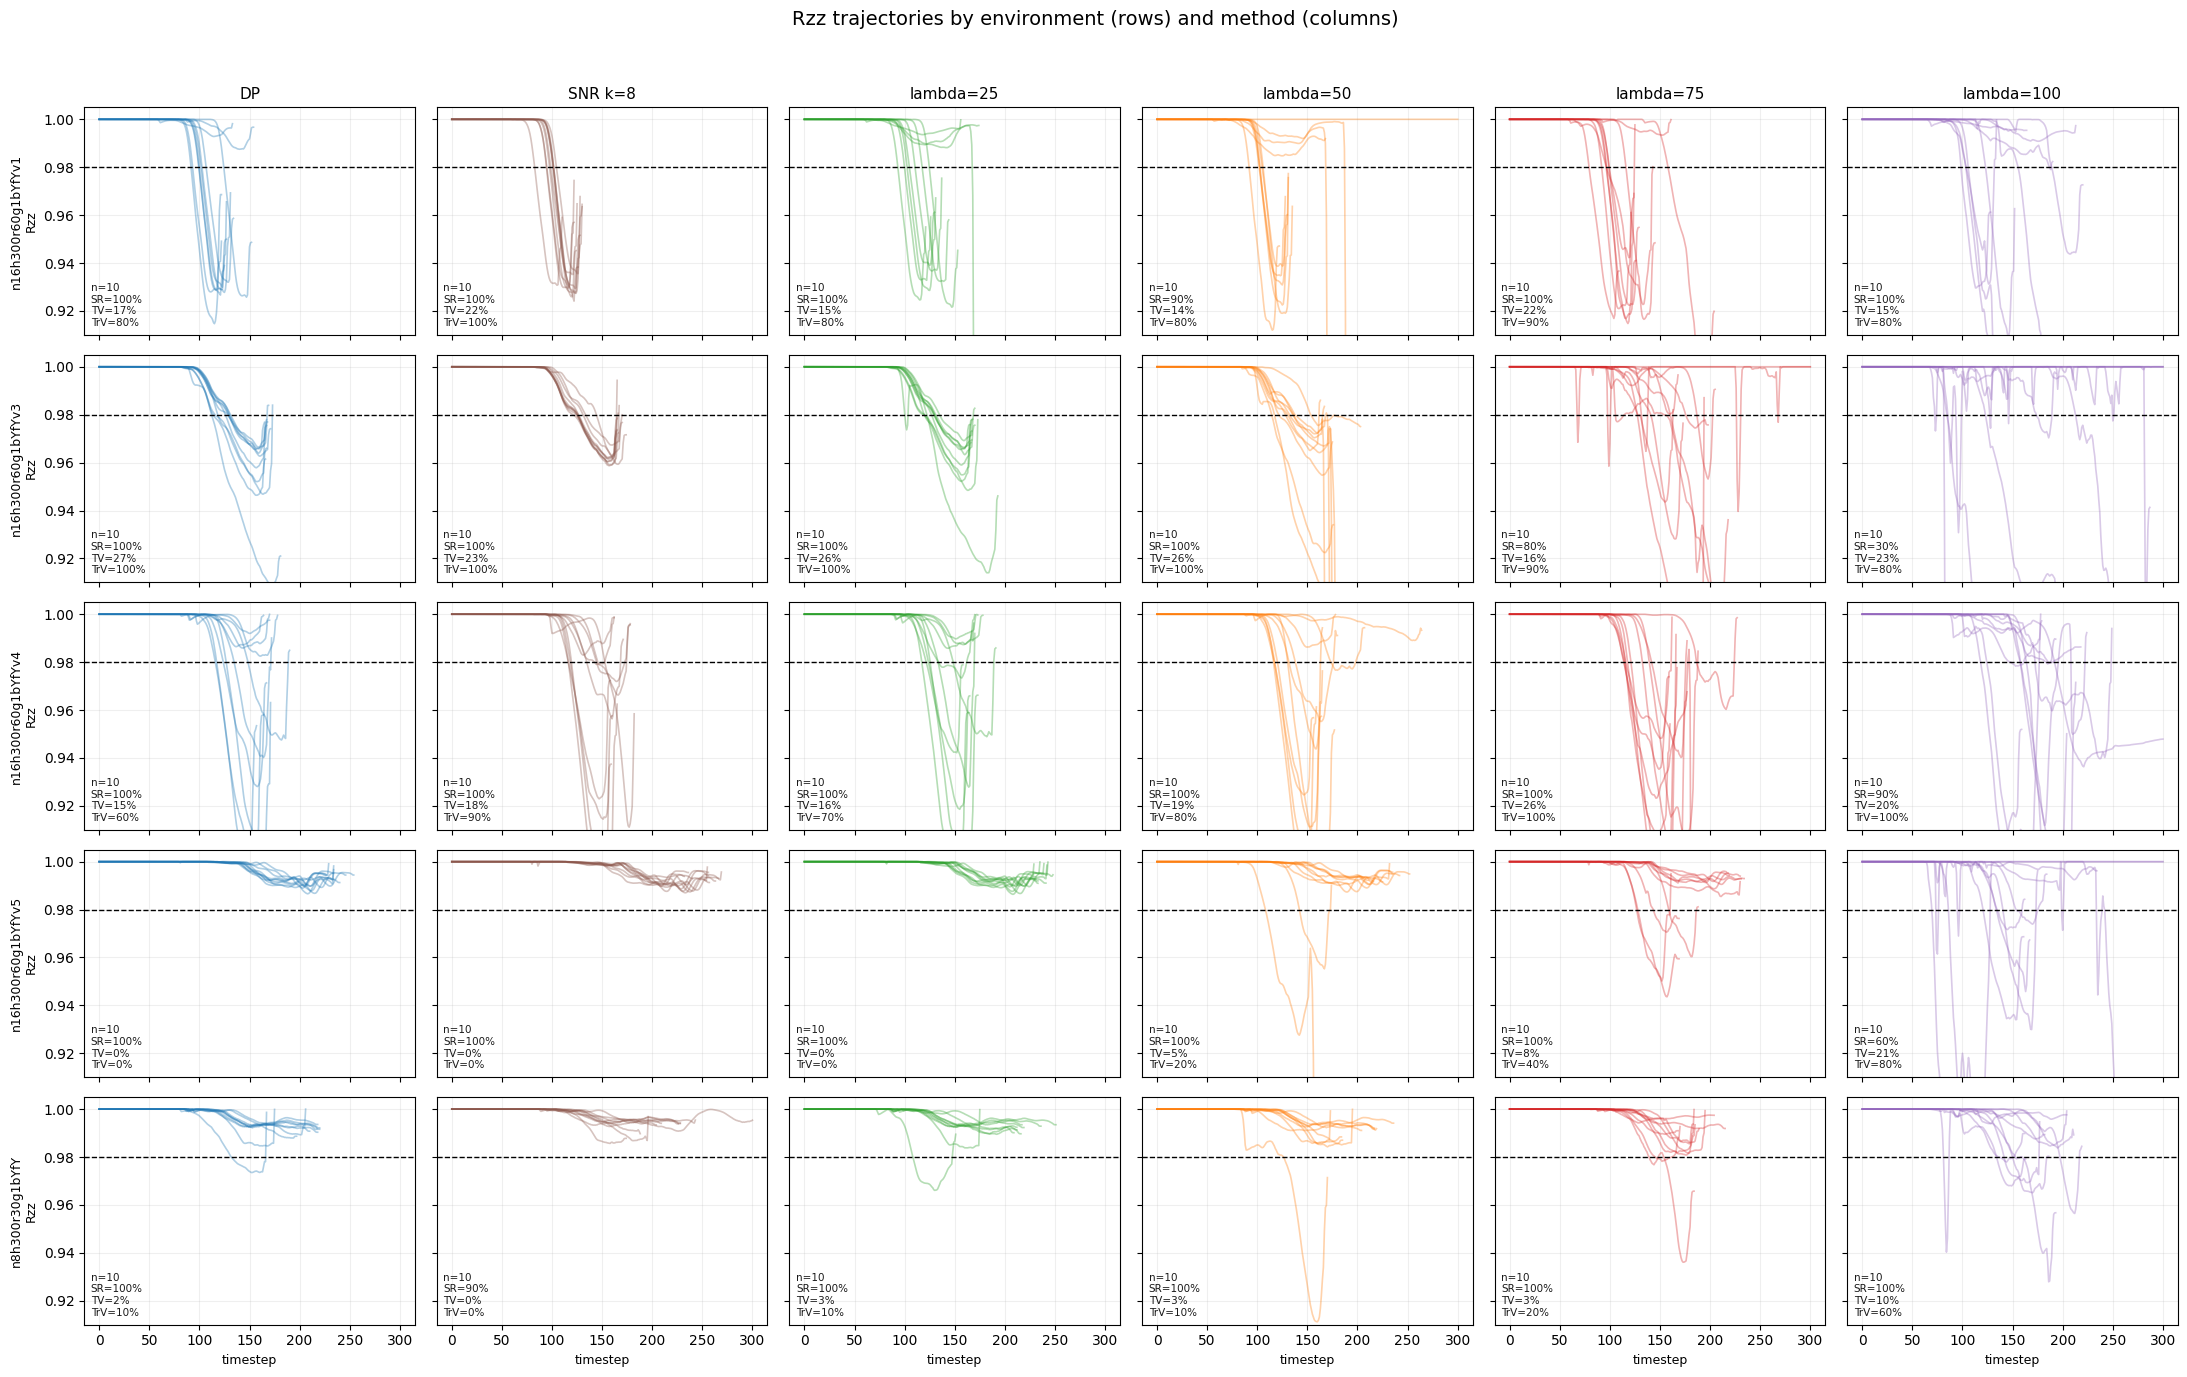

total plotted curves: 300
threshold: 0.98
shared y-limits: [0.91, 1.005]

Overall average metrics by method
Method         SR(%)   TV(%)  TrV(%)
----------------------------------
DP             100.0    12.3    50.0
SNR k=8         98.0    12.7    58.0
lambda=25      100.0    11.9    52.0
lambda=50       98.0    13.1    58.0
lambda=75       96.0    14.9    68.0
lambda=100      76.0    17.7    80.0


In [ ]:
# Comparing method effect: all 10 rollouts per method and environment

from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

# 5x6 grid: rows=envs, cols=methods
run_root = Path("/scratch/gilbreth/zoellner/diffusion_rollouts/can_rollouts/comparison/20260404_171101")

envs = [
    "n16h300r60g1bYfYv1",
    "n16h300r60g1bYfYv3",
    "n16h300r60g1bYfYv4",
    "n16h300r60g1bYfYv5",
    "n8h300r30g1bYfY",
]
methods = [
    "dp_base",
    "snr_k8",
    "dp_guidance_l25",
    "dp_guidance_l50",
    "dp_guidance_l75",
    "dp_guidance_l100",
]

method_labels = {
    "dp_base": "DP",
    "snr_k8": "SNR k=8",
    "dp_guidance_l25": "lambda=25",
    "dp_guidance_l50": "lambda=50",
    "dp_guidance_l75": "lambda=75",
    "dp_guidance_l100": "lambda=100",
}

method_colors = {
    "dp_base": "#1f77b4",
    "snr_k8": "#8c564b",
    "dp_guidance_l25": "#2ca02c",
    "dp_guidance_l50": "#ff7f0e",
    "dp_guidance_l75": "#d62728",
    "dp_guidance_l100": "#9467bd",
}

threshold = 0.98
ymin, ymax = 0.91, 1.005

fig, axes = plt.subplots(len(envs), len(methods), figsize=(22, 14), sharex=True, sharey=True)

total_plotted = 0
method_to_success_flags = {m: [] for m in methods}
method_to_timestep_violation_rates = {m: [] for m in methods}
method_to_trajectory_violation_flags = {m: [] for m in methods}

for i, env_name in enumerate(envs):
    for j, m in enumerate(methods):
        ax = axes[i, j]
        rows_path = run_root / m / "rollout_rows.jsonl"
        with rows_path.open("r", encoding="utf-8") as f:
            rows = [json.loads(line) for line in f if line.strip()]

        n_curves = 0
        success_flags = []
        timestep_violation_rates = []
        trajectory_violation_flags = []

        for r in rows:
            if r.get("init_name") != env_name:
                continue

            npz_path = run_root / m / f"{env_name}__seed_{int(r['seed']):02d}" / "rollout_numeric.npz"
            if not npz_path.exists():
                continue

            success_flag = float(bool(r.get("success", False)))
            success_flags.append(success_flag)
            method_to_success_flags[m].append(success_flag)

            rzz = np.load(npz_path)["rzz_mujoco"]
            below_threshold = rzz < threshold
            timestep_vr = float(np.mean(below_threshold) * 100.0)
            trajectory_vr = float(np.any(below_threshold) * 100.0)

            timestep_violation_rates.append(timestep_vr)
            trajectory_violation_flags.append(trajectory_vr)
            method_to_timestep_violation_rates[m].append(timestep_vr)
            method_to_trajectory_violation_flags[m].append(trajectory_vr)

            ax.plot(rzz, color=method_colors[m], alpha=0.35, lw=1.2)
            n_curves += 1
            total_plotted += 1

        sr = 100.0 * np.mean(success_flags) if success_flags else float("nan")
        timestep_vr = float(np.mean(timestep_violation_rates)) if timestep_violation_rates else float("nan")
        trajectory_vr = float(np.mean(trajectory_violation_flags)) if trajectory_violation_flags else float("nan")

        ax.axhline(threshold, color="black", linestyle="--", linewidth=1.0)
        ax.set_ylim(ymin, ymax)
        ax.grid(alpha=0.2)

        if i == 0:
            ax.set_title(method_labels[m], fontsize=11)
        if j == 0:
            ax.set_ylabel(f"{env_name}\nRzz", fontsize=9)
        if i == len(envs) - 1:
            ax.set_xlabel("timestep", fontsize=9)

        ax.text(
            0.02,
            0.04,
            f"n={n_curves}\nSR={sr:.0f}%\nTV={timestep_vr:.0f}%\nTrV={trajectory_vr:.0f}%",
            transform=ax.transAxes,
            fontsize=7.5,
            alpha=0.9,
        )

fig.suptitle("Rzz trajectories by environment (rows) and method (columns)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print(f"total plotted curves: {total_plotted}")
print(f"threshold: {threshold}")
print(f"shared y-limits: [{ymin}, {ymax}]")
print()
print("Overall average metrics by method")
print(f"{'Method':<12} {'SR(%)':>7} {'TV(%)':>7} {'TrV(%)':>7}")
print("----------------------------------")
for m in methods:
    sr_vals = method_to_success_flags[m]
    tv_vals = method_to_timestep_violation_rates[m]
    trv_vals = method_to_trajectory_violation_flags[m]
    sr = 100.0 * np.mean(sr_vals) if sr_vals else float("nan")
    tv = float(np.mean(tv_vals)) if tv_vals else float("nan")
    trv = float(np.mean(trv_vals)) if trv_vals else float("nan")
    print(f"{method_labels[m]:<12} {sr:>7.1f} {tv:>7.1f} {trv:>7.1f}")

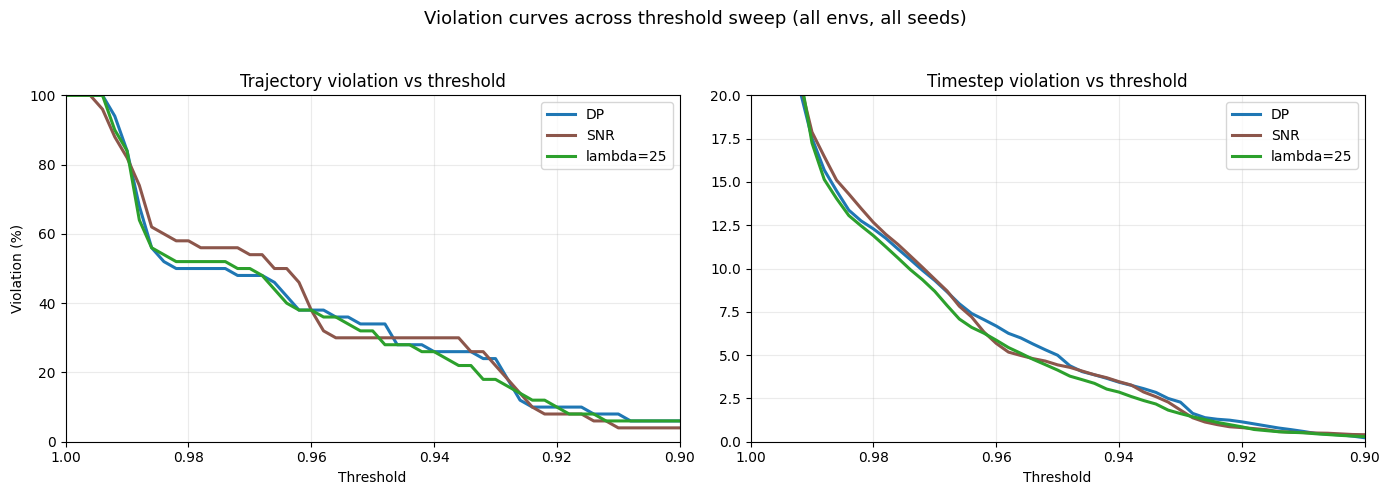

rollouts used per method:
- DP: 50
- SNR: 50
- lambda=25: 50
threshold range: 1.00 -> 0.90 (51 points)


In [ ]:
# Checking how much we can improve violation: threshold vs violation rates

from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

# Threshold-sweep violation curves
# Left: trajectory violation (% rollouts that ever go below threshold)
# Right: timestep violation (% timesteps below threshold, averaged over rollouts)
run_root = Path("/scratch/gilbreth/zoellner/diffusion_rollouts/can_rollouts/comparison/20260404_171101")

envs = [
    "n16h300r60g1bYfYv1",
    "n16h300r60g1bYfYv3",
    "n16h300r60g1bYfYv4",
    "n16h300r60g1bYfYv5",
    "n8h300r30g1bYfY",
]

# Compare exactly DP, SNR, and one lambda method.
METHODS = {
    "dp_base": "DP",
    "snr_k8": "SNR",
    "dp_guidance_l25": "lambda=25",
}

COLORS = {
    "dp_base": "#1f77b4",
    "snr_k8": "#8c564b",
    "dp_guidance_l25": "#2ca02c",
}

# User-requested sweep direction: start at 1.00 and decrease to 0.90.
thresholds = np.linspace(1.00, 0.90, 51)

method_to_rollouts = {m: [] for m in METHODS}
for m in METHODS:
    rows_path = run_root / m / "rollout_rows.jsonl"
    with rows_path.open("r", encoding="utf-8") as f:
        rows = [json.loads(line) for line in f if line.strip()]

    for r in rows:
        if r.get("init_name") not in envs:
            continue

        npz_path = run_root / m / f"{r['init_name']}__seed_{int(r['seed']):02d}" / "rollout_numeric.npz"
        if not npz_path.exists():
            continue

        rzz = np.load(npz_path)["rzz_mujoco"]
        method_to_rollouts[m].append(np.asarray(rzz, dtype=np.float32))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
ax_traj, ax_time = axes

for m, label in METHODS.items():
    rollouts = method_to_rollouts[m]
    if not rollouts:
        continue

    traj_curve = []
    time_curve = []

    for thr in thresholds:
        per_rollout_timestep = [100.0 * float(np.mean(rzz < thr)) for rzz in rollouts]
        per_rollout_trajectory = [100.0 * float(np.any(rzz < thr)) for rzz in rollouts]

        time_curve.append(float(np.mean(per_rollout_timestep)))
        traj_curve.append(float(np.mean(per_rollout_trajectory)))

    ax_traj.plot(thresholds, traj_curve, lw=2.2, color=COLORS[m], label=label)
    ax_time.plot(thresholds, time_curve, lw=2.2, color=COLORS[m], label=label)

ax_traj.set_title("Trajectory violation vs threshold")
ax_traj.set_ylabel("Violation (%)")
ax_traj.set_xlabel("Threshold")
ax_traj.grid(alpha=0.25)

ax_time.set_title("Timestep violation vs threshold")
ax_time.set_xlabel("Threshold")
ax_time.grid(alpha=0.25)

ax_traj.set_ylim(0, 100)
ax_time.set_ylim(0, 20)
ax_traj.legend(frameon=True)
ax_time.legend(frameon=True)

# Keep x-axis descending so the left side is 1.00 and right side is 0.90.
ax_traj.set_xlim(1.00, 0.90)
ax_time.set_xlim(1.00, 0.90)

fig.suptitle("Violation curves across threshold sweep (all envs, all seeds)", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("rollouts used per method:")
for m, label in METHODS.items():
    print(f"- {label}: {len(method_to_rollouts[m])}")
print(f"threshold range: {thresholds[0]:.2f} -> {thresholds[-1]:.2f} ({len(thresholds)} points)")

### One inital state (v1), ran over 50 seeds

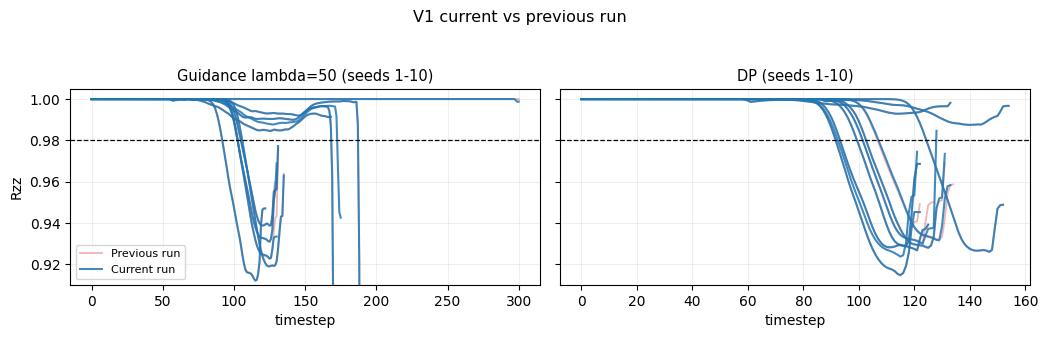

current run root: /scratch/gilbreth/zoellner/diffusion_rollouts/can_rollouts/comparison/20260407_210830_v1_s1_50
previous run root: /scratch/gilbreth/zoellner/diffusion_rollouts/can_rollouts/comparison/20260404_171101

Guidance lambda=50 (dp_guidance_l50)
  current plotted seeds: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
  previous plotted seeds: [1, 2, 3, 4, 5, 6, 7, 8, 9]
  current missing seeds: []
  previous missing seeds: [10]

DP (dp_base)
  current plotted seeds: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
  previous plotted seeds: [1, 2, 3, 4, 5, 6, 7, 8, 9]
  current missing seeds: []
  previous missing seeds: [10]


In [5]:
# Sanity check: Are we doing the same thing as last time?
# Compact 2-panel plot: left = lambda 50, right = DP.

from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

base_dir = Path("/scratch/gilbreth/zoellner/diffusion_rollouts/can_rollouts/comparison")
previous_run_root = base_dir / "20260404_171101"  # folder referenced in the previous cell

# Auto-pick the newest run folder (excluding previous) as the current run.
run_dirs = sorted([p for p in base_dir.iterdir() if p.is_dir() and p.name != previous_run_root.name])
if not run_dirs:
    raise RuntimeError("No comparison run directories found besides the previous run.")
current_run_root = run_dirs[-1]

env_name = "n16h300r60g1bYfYv1"
seed_range = range(1, 11)
threshold = 0.98
ymin, ymax = 0.91, 1.005

# Left then right, per user request.
method_specs = [
    ("dp_guidance_l50", "Guidance lambda=50"),
    ("dp_base", "DP"),
]

color_current = "#1f77b4"
color_previous = "#d62728"


def load_seed_to_rzz(run_root: Path, method_slug: str):
    rows_path = run_root / method_slug / "rollout_rows.jsonl"
    if not rows_path.exists():
        return {}

    with rows_path.open("r", encoding="utf-8") as f:
        rows = [json.loads(line) for line in f if line.strip()]

    seed_to_rzz = {}
    for r in rows:
        if r.get("init_name") != env_name:
            continue

        seed = int(r["seed"])
        if seed not in seed_range:
            continue

        npz_path = run_root / method_slug / f"{env_name}__seed_{seed:02d}" / "rollout_numeric.npz"
        if npz_path.exists():
            seed_to_rzz[seed] = np.load(npz_path)["rzz_mujoco"]

    return seed_to_rzz


fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.4), sharey=True)
if not isinstance(axes, np.ndarray):
    axes = np.array([axes])

for ax, (method_slug, title_label) in zip(axes, method_specs):
    current_seed_to_rzz = load_seed_to_rzz(current_run_root, method_slug)
    previous_seed_to_rzz = load_seed_to_rzz(previous_run_root, method_slug)

    # Plot previous first, then current on top for clearer visual comparison.
    for i, seed in enumerate(seed_range):
        rzz_prev = previous_seed_to_rzz.get(seed)
        if rzz_prev is not None:
            ax.plot(
                rzz_prev,
                color=color_previous,
                lw=1.3,
                alpha=0.35,
                label="Previous run" if i == 0 else None,
            )

    for i, seed in enumerate(seed_range):
        rzz_cur = current_seed_to_rzz.get(seed)
        if rzz_cur is not None:
            ax.plot(
                rzz_cur,
                color=color_current,
                lw=1.5,
                alpha=0.85,
                label="Current run" if i == 0 else None,
            )

    ax.axhline(threshold, color="black", linestyle="--", linewidth=0.9)
    ax.set_title(f"{title_label} (seeds 1-10)", fontsize=10.5)
    ax.set_xlabel("timestep")
    ax.set_ylim(ymin, ymax)
    ax.grid(alpha=0.2)

axes[0].set_ylabel("Rzz")
axes[0].legend(frameon=True, fontsize=8)

fig.suptitle("V1 current vs previous run", fontsize=11.5)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

print(f"current run root: {current_run_root}")
print(f"previous run root: {previous_run_root}")

for method_slug, title_label in method_specs:
    cur = load_seed_to_rzz(current_run_root, method_slug)
    prev = load_seed_to_rzz(previous_run_root, method_slug)
    print(f"\n{title_label} ({method_slug})")
    print(f"  current plotted seeds: {sorted(cur)}")
    print(f"  previous plotted seeds: {sorted(prev)}")
    print("  current missing seeds:", [s for s in seed_range if s not in cur])
    print("  previous missing seeds:", [s for s in seed_range if s not in prev])

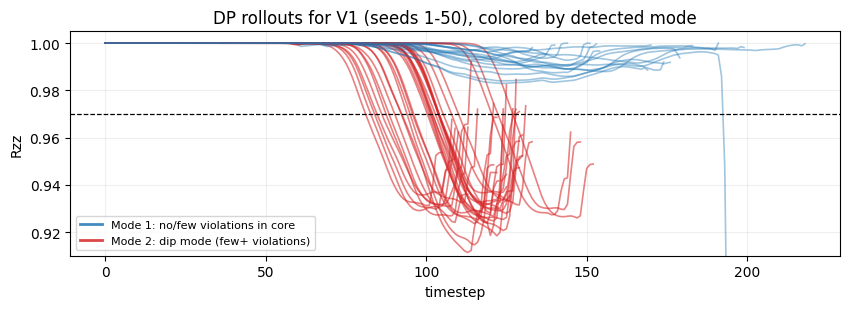

run root: /scratch/gilbreth/zoellner/diffusion_rollouts/can_rollouts/comparison/20260407_210830_v1_s1_50
method: dp_base | env: n16h300r60g1bYfYv1
plotted rollouts: 50 / 50
success rate: 100.00%
core window fractions: [0.00, 0.90]
threshold: 0.97
mode 2 violation-step trigger: 3
mode 1 percentage: 34.00% (17/50)
mode 2 percentage: 66.00% (33/50)
mean violations in core window: 8.10
missing seeds: []


In [6]:
# Plot all 50 DP rollouts for V1, split into two execution modes, and report percentages.

from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

base_dir = Path("/scratch/gilbreth/zoellner/diffusion_rollouts/can_rollouts/comparison")
method_slug = "dp_base"
env_name = "n16h300r60g1bYfYv1"
seed_range = range(1, 51)
threshold = 0.97
ymin, ymax = 0.91, 1.005

# Mode detection window and rule (per user request):
# - core window is [0%, 90%] of each rollout
# - as soon as there are a few violating timesteps, classify as mode 2
core_start_fraction = 0.00
core_end_fraction = 0.90
violation_steps_for_mode2 = 3

# Prefer the current run chosen in the previous cell if available.
if "current_run_root" in globals():
    run_root = Path(current_run_root)
else:
    run_dirs = sorted([p for p in base_dir.iterdir() if p.is_dir()])
    if not run_dirs:
        raise RuntimeError("No comparison run directories found.")
    run_root = run_dirs[-1]

rows_path = run_root / method_slug / "rollout_rows.jsonl"
if not rows_path.exists():
    raise FileNotFoundError(f"Missing rows file: {rows_path}")

with rows_path.open("r", encoding="utf-8") as f:
    rows = [json.loads(line) for line in f if line.strip()]

seed_to_rzz = {}
seed_to_success = {}

for r in rows:
    if r.get("init_name") != env_name:
        continue

    seed = int(r.get("seed", -1))
    if seed not in seed_range:
        continue

    npz_path = run_root / method_slug / f"{env_name}__seed_{seed:02d}" / "rollout_numeric.npz"
    if not npz_path.exists():
        continue

    rzz = np.load(npz_path)["rzz_mujoco"]
    seed_to_rzz[seed] = np.asarray(rzz, dtype=np.float32)
    seed_to_success[seed] = float(bool(r.get("success", False)))

# Classify mode per rollout.
# mode 2 if violation count in core window reaches threshold; else mode 1.
seed_to_mode = {}
seed_to_violation_count = {}
for seed, rzz in seed_to_rzz.items():
    n = len(rzz)
    i0 = max(0, min(n - 1, int(n * core_start_fraction)))
    i1 = min(n, max(i0 + 1, int(n * core_end_fraction)))
    rzz_core = rzz[i0:i1]

    violation_count = int(np.sum(rzz_core < threshold))
    seed_to_violation_count[seed] = violation_count
    seed_to_mode[seed] = 2 if violation_count >= violation_steps_for_mode2 else 1

fig, ax = plt.subplots(figsize=(8.6, 3.2))

for seed in seed_range:
    rzz = seed_to_rzz.get(seed)
    if rzz is None:
        continue

    mode = seed_to_mode[seed]
    color = "#1f77b4" if mode == 1 else "#d62728"
    alpha = 0.42 if mode == 1 else 0.58
    ax.plot(rzz, color=color, lw=1.2, alpha=alpha)

ax.axhline(threshold, color="black", linestyle="--", linewidth=0.9)
ax.set_title("DP rollouts for V1 (seeds 1-50), colored by detected mode")
ax.set_xlabel("timestep")
ax.set_ylabel("Rzz")
ax.set_ylim(ymin, ymax)
ax.grid(alpha=0.2)

# Legend handles for mode colors.
ax.plot([], [], color="#1f77b4", lw=2.0, alpha=0.85, label="Mode 1: no/few violations in core")
ax.plot([], [], color="#d62728", lw=2.0, alpha=0.85, label="Mode 2: dip mode (few+ violations)")
ax.legend(frameon=True, fontsize=8)

plt.tight_layout()
plt.show()

plotted_seeds = sorted(seed_to_rzz)
missing_seeds = [s for s in seed_range if s not in seed_to_rzz]
success_vals = [seed_to_success[s] for s in plotted_seeds if s in seed_to_success]
success_rate = 100.0 * float(np.mean(success_vals)) if success_vals else float("nan")

mode1_count = sum(1 for s in plotted_seeds if seed_to_mode.get(s) == 1)
mode2_count = sum(1 for s in plotted_seeds if seed_to_mode.get(s) == 2)
total = len(plotted_seeds)
mode1_pct = 100.0 * mode1_count / total if total else float("nan")
mode2_pct = 100.0 * mode2_count / total if total else float("nan")

print(f"run root: {run_root}")
print(f"method: {method_slug} | env: {env_name}")
print(f"plotted rollouts: {total} / {len(list(seed_range))}")
print(f"success rate: {success_rate:.2f}%")
print(f"core window fractions: [{core_start_fraction:.2f}, {core_end_fraction:.2f}]")
print(f"threshold: {threshold:.2f}")
print(f"mode 2 violation-step trigger: {violation_steps_for_mode2}")
print(f"mode 1 percentage: {mode1_pct:.2f}% ({mode1_count}/{total})")
print(f"mode 2 percentage: {mode2_pct:.2f}% ({mode2_count}/{total})")
print(f"mean violations in core window: {np.mean([seed_to_violation_count[s] for s in plotted_seeds]):.2f}")
print(f"missing seeds: {missing_seeds}")

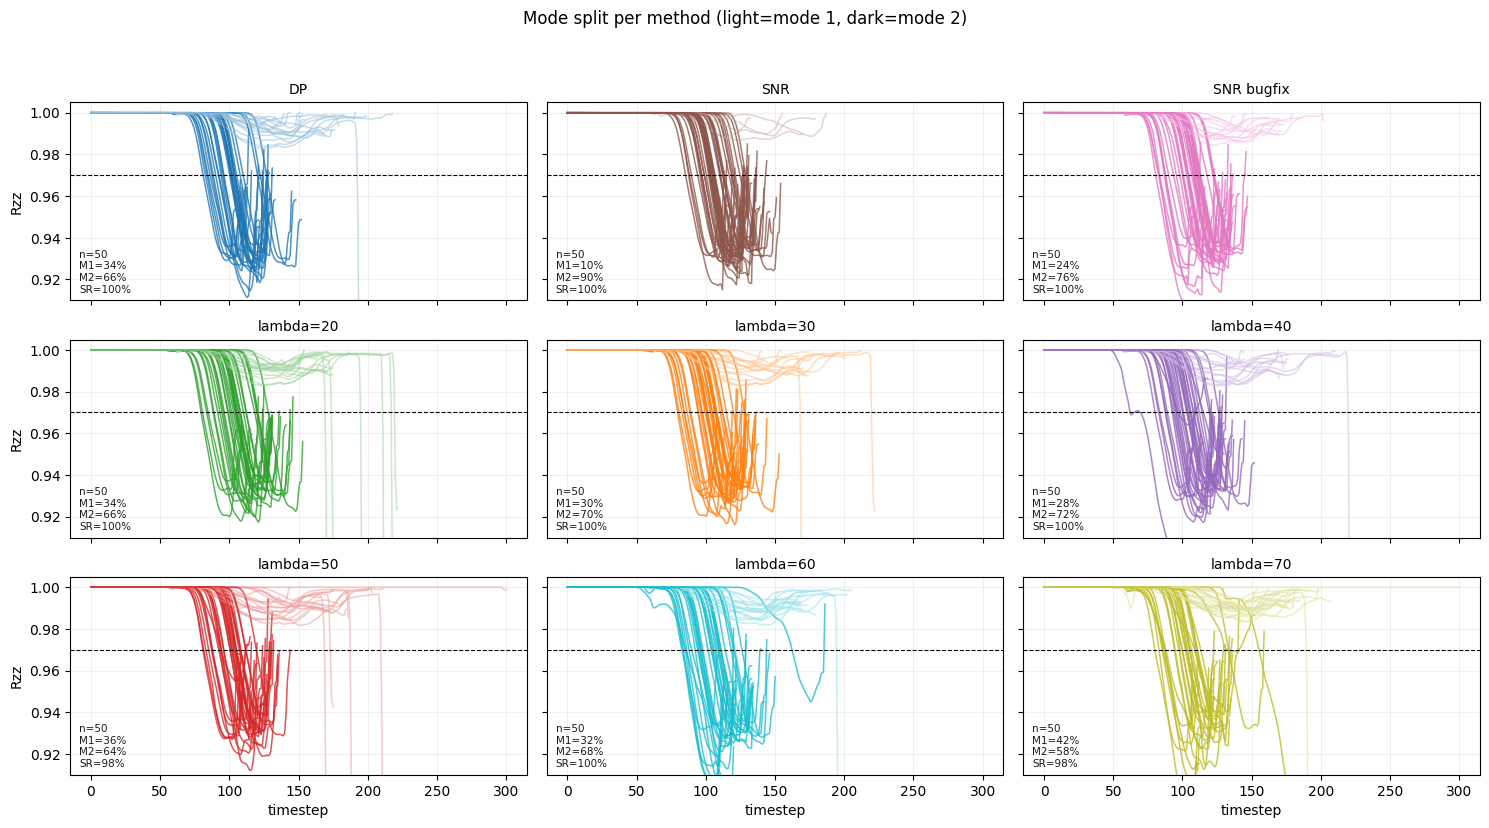

run root: /scratch/gilbreth/zoellner/diffusion_rollouts/can_rollouts/comparison/20260407_210830_v1_s1_50
env: n16h300r60g1bYfYv1 | threshold: 0.97 | core window: [0.00, 0.90]
mode 2 trigger: >= 3 violations in core window

Method                N   Mode1 %   Mode2 %  Success %     Avg_Rzz (core)    Avg_Rzz M1 (core)    Avg_Rzz M2 (core)     Timestep_VFrac(core)
----------------------------------------------------------------------------------------------------------------------------------------
DP                   50    34.00%    66.00%    100.00%             0.9945               0.9975               0.9930                   0.0733
SNR                  50    10.00%    90.00%    100.00%   -0.0001 (0.9944)     +0.0001 (0.9976)     +0.0011 (0.9941)         +0.0118 (0.0852)
SNR bugfix           50    24.00%    76.00%    100.00%   -0.0000 (0.9945)     -0.0005 (0.9970)     +0.0007 (0.9937)         +0.0020 (0.0753)
lambda=20            50    34.00%    66.00%    100.00%   +0.0001 (0.9946)   

In [2]:
# Mode split per method: method-specific color family, light=mode 1, dark=mode 2.

from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors

base_dir = Path("/scratch/gilbreth/zoellner/diffusion_rollouts/can_rollouts/comparison")
env_name = "n16h300r60g1bYfYv1"
seed_range = range(1, 51)
threshold = 0.97
ymin, ymax = 0.91, 1.005

core_start_fraction = 0.00
core_end_fraction = 0.90
violation_steps_for_mode2 = 3

# Prefer current run from earlier cells if available.
if "current_run_root" in globals():
    run_root = Path(current_run_root)
else:
    run_dirs = sorted([p for p in base_dir.iterdir() if p.is_dir()])
    if not run_dirs:
        raise RuntimeError("No comparison run directories found.")
    run_root = run_dirs[-1]

# Include all method directories; some (e.g., bugfix runs) may not have rollout_rows.jsonl.
methods = [p.name for p in sorted(run_root.iterdir()) if p.is_dir()]

# Keep a consistent method order.
preferred_order = [
    "dp_base",
    "snr_k8",
    "snr_k8_bugfix",
    "dp_guidance_l20",
    "dp_guidance_l30",
    "dp_guidance_l40",
    "dp_guidance_l50",
    "dp_guidance_l60",
    "dp_guidance_l70",
]
methods = [m for m in preferred_order if m in methods] + [m for m in methods if m not in preferred_order]

method_labels = {
    "dp_base": "DP",
    "snr_k8": "SNR",
    "snr_k8_bugfix": "SNR bugfix",
    "dp_guidance_l20": "lambda=20",
    "dp_guidance_l30": "lambda=30",
    "dp_guidance_l40": "lambda=40",
    "dp_guidance_l50": "lambda=50",
    "dp_guidance_l60": "lambda=60",
    "dp_guidance_l70": "lambda=70",
}

# One base color per method; mode 1 uses a lighter tint.
method_base_colors = {
    "dp_base": "#1f77b4",
    "snr_k8": "#8c564b",
    "snr_k8_bugfix": "#e377c2",
    "dp_guidance_l20": "#2ca02c",
    "dp_guidance_l30": "#ff7f0e",
    "dp_guidance_l40": "#9467bd",
    "dp_guidance_l50": "#d62728",
    "dp_guidance_l60": "#17becf",
    "dp_guidance_l70": "#bcbd22",
}


def lighten_color(color, amount=0.6):
    r, g, b = mcolors.to_rgb(color)
    return (1 - amount) + amount * r, (1 - amount) + amount * g, (1 - amount) + amount * b


def _load_method_rollouts(method_slug):
    seed_to_rzz = {}
    seed_to_success = {}

    rows_path = run_root / method_slug / "rollout_rows.jsonl"
    if rows_path.exists():
        with rows_path.open("r", encoding="utf-8") as f:
            rows = [json.loads(line) for line in f if line.strip()]

        for r in rows:
            if r.get("init_name") != env_name:
                continue
            seed = int(r.get("seed", -1))
            if seed not in seed_range:
                continue

            npz_path = run_root / method_slug / f"{env_name}__seed_{seed:02d}" / "rollout_numeric.npz"
            if not npz_path.exists():
                continue

            seed_to_rzz[seed] = np.asarray(np.load(npz_path)["rzz_mujoco"], dtype=np.float32)
            seed_to_success[seed] = float(bool(r.get("success", False)))
        return seed_to_rzz, seed_to_success

    # Fallback for folders without rollout_rows.jsonl (e.g. snr_k8_bugfix).
    for seed in seed_range:
        candidate_dirs = [
            run_root / method_slug / f"{env_name}__seed_{seed:02d}",
            run_root / method_slug / f"{env_name}_seed{seed}",
            run_root / method_slug / f"{env_name}_seed_{seed:02d}",
        ]
        rollout_dir = next((d for d in candidate_dirs if d.exists()), None)
        if rollout_dir is None:
            continue

        npz_path = rollout_dir / "rollout_numeric.npz"
        if not npz_path.exists():
            continue

        seed_to_rzz[seed] = np.asarray(np.load(npz_path)["rzz_mujoco"], dtype=np.float32)

        stats_path = rollout_dir / "rollout_stats.json"
        if stats_path.exists():
            with stats_path.open("r", encoding="utf-8") as f:
                stats = json.load(f)
            seed_to_success[seed] = float(bool(stats.get("success", False)))

    return seed_to_rzz, seed_to_success


n_methods = len(methods)
ncols = 3
nrows = int(np.ceil(n_methods / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.0 * ncols, 2.8 * nrows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

summary_rows = []

for ax, method_slug in zip(axes, methods):
    seed_to_rzz, seed_to_success = _load_method_rollouts(method_slug)

    seed_to_mode = {}
    per_rollout_core_mean_rzz = []
    per_rollout_core_timestep_vfrac = []
    per_mode_core_mean_rzz = {1: [], 2: []}

    for seed, rzz in seed_to_rzz.items():
        n = len(rzz)
        i0 = max(0, min(n - 1, int(n * core_start_fraction)))
        i1 = min(n, max(i0 + 1, int(n * core_end_fraction)))
        rzz_core = rzz[i0:i1]

        violation_count = int(np.sum(rzz_core < threshold))
        seed_to_mode[seed] = 2 if violation_count >= violation_steps_for_mode2 else 1

        core_mean_rzz = float(np.mean(rzz_core))
        per_rollout_core_mean_rzz.append(core_mean_rzz)
        per_rollout_core_timestep_vfrac.append(float(np.mean(rzz_core < threshold)))
        per_mode_core_mean_rzz[seed_to_mode[seed]].append(core_mean_rzz)

    base_color = method_base_colors.get(method_slug, "#4c4c4c")
    light_color = lighten_color(base_color, amount=0.45)
    dark_color = mcolors.to_rgb(base_color)

    for seed in seed_range:
        rzz = seed_to_rzz.get(seed)
        if rzz is None:
            continue

        mode = seed_to_mode[seed]
        color = light_color if mode == 1 else dark_color
        alpha = 0.55 if mode == 1 else 0.78
        ax.plot(rzz, color=color, lw=1.1, alpha=alpha)

    ax.axhline(threshold, color="black", linestyle="--", linewidth=0.8)
    ax.set_title(method_labels.get(method_slug, method_slug), fontsize=10)
    ax.grid(alpha=0.2)
    ax.set_ylim(ymin, ymax)

    total = len(seed_to_rzz)
    mode1_count = sum(1 for s in seed_to_rzz if seed_to_mode.get(s) == 1)
    mode2_count = sum(1 for s in seed_to_rzz if seed_to_mode.get(s) == 2)
    mode1_pct = (100.0 * mode1_count / total) if total else float("nan")
    mode2_pct = (100.0 * mode2_count / total) if total else float("nan")
    success_vals = [seed_to_success[s] for s in seed_to_rzz if s in seed_to_success]
    success_pct = (100.0 * float(np.mean(success_vals))) if success_vals else float("nan")

    avg_rzz_core = float(np.mean(per_rollout_core_mean_rzz)) if per_rollout_core_mean_rzz else float("nan")
    timestep_vfrac_core = float(np.mean(per_rollout_core_timestep_vfrac)) if per_rollout_core_timestep_vfrac else float("nan")
    avg_rzz_mode1 = float(np.mean(per_mode_core_mean_rzz[1])) if per_mode_core_mean_rzz[1] else float("nan")
    avg_rzz_mode2 = float(np.mean(per_mode_core_mean_rzz[2])) if per_mode_core_mean_rzz[2] else float("nan")

    summary_rows.append(
        {
            "method_slug": method_slug,
            "label": method_labels.get(method_slug, method_slug),
            "N": total,
            "mode1_pct": mode1_pct,
            "mode2_pct": mode2_pct,
            "success_pct": success_pct,
            "avg_rzz_core": avg_rzz_core,
            "avg_rzz_mode1": avg_rzz_mode1,
            "avg_rzz_mode2": avg_rzz_mode2,
            "timestep_vfrac_core": timestep_vfrac_core,
        }
    )

    ax.text(
        0.02,
        0.04,
        f"n={total}\nM1={mode1_pct:.0f}%\nM2={mode2_pct:.0f}%\nSR={success_pct:.0f}%",
        transform=ax.transAxes,
        fontsize=7.5,
        alpha=0.9,
    )

# Hide unused axes.
for ax in axes[n_methods:]:
    ax.axis("off")

for r in range(nrows):
    axes[r * ncols].set_ylabel("Rzz")
for c in range(ncols):
    idx = (nrows - 1) * ncols + c
    if idx < len(axes):
        axes[idx].set_xlabel("timestep")

fig.suptitle("Mode split per method (light=mode 1, dark=mode 2)", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print(f"run root: {run_root}")
print(f"env: {env_name} | threshold: {threshold:.2f} | core window: [{core_start_fraction:.2f}, {core_end_fraction:.2f}]")
print(f"mode 2 trigger: >= {violation_steps_for_mode2} violations in core window")
print()

base_row = next((r for r in summary_rows if r["method_slug"] == "dp_base"), None)
if base_row is None:
    raise RuntimeError("Base policy (dp_base) not found in summary rows.")

base_avg_rzz = base_row["avg_rzz_core"]
base_rzz_mode1 = base_row["avg_rzz_mode1"]
base_rzz_mode2 = base_row["avg_rzz_mode2"]
base_tvf = base_row["timestep_vfrac_core"]

print(
    f"{'Method':<18} {'N':>4} {'Mode1 %':>9} {'Mode2 %':>9} {'Success %':>10} {'Avg_Rzz (core)':>18} {'Avg_Rzz M1 (core)':>20} {'Avg_Rzz M2 (core)':>20} {'Timestep_VFrac(core)':>24}"
)
print("-" * 136)

for row in summary_rows:
    label = row["label"]
    n = row["N"]
    m1 = row["mode1_pct"]
    m2 = row["mode2_pct"]
    sr = row["success_pct"]
    avg_rzz = row["avg_rzz_core"]
    avg_rzz_mode1 = row["avg_rzz_mode1"]
    avg_rzz_mode2 = row["avg_rzz_mode2"]
    tvf = row["timestep_vfrac_core"]

    if row["method_slug"] == "dp_base":
        avg_rzz_col = f"{avg_rzz:.4f}"
        avg_rzz_mode1_col = f"{avg_rzz_mode1:.4f}"
        avg_rzz_mode2_col = f"{avg_rzz_mode2:.4f}"
        tvf_col = f"{tvf:.4f}"
    else:
        delta_rzz = avg_rzz - base_avg_rzz
        delta_rzz_mode1 = avg_rzz_mode1 - base_rzz_mode1
        delta_rzz_mode2 = avg_rzz_mode2 - base_rzz_mode2
        delta_tvf = tvf - base_tvf
        avg_rzz_col = f"{delta_rzz:+.4f} ({avg_rzz:.4f})"
        avg_rzz_mode1_col = f"{delta_rzz_mode1:+.4f} ({avg_rzz_mode1:.4f})"
        avg_rzz_mode2_col = f"{delta_rzz_mode2:+.4f} ({avg_rzz_mode2:.4f})"
        tvf_col = f"{delta_tvf:+.4f} ({tvf:.4f})"

    print(
        f"{label:<18} {n:>4} {m1:>8.2f}% {m2:>8.2f}% {sr:>9.2f}% {avg_rzz_col:>18} {avg_rzz_mode1_col:>20} {avg_rzz_mode2_col:>20} {tvf_col:>24}"
    )

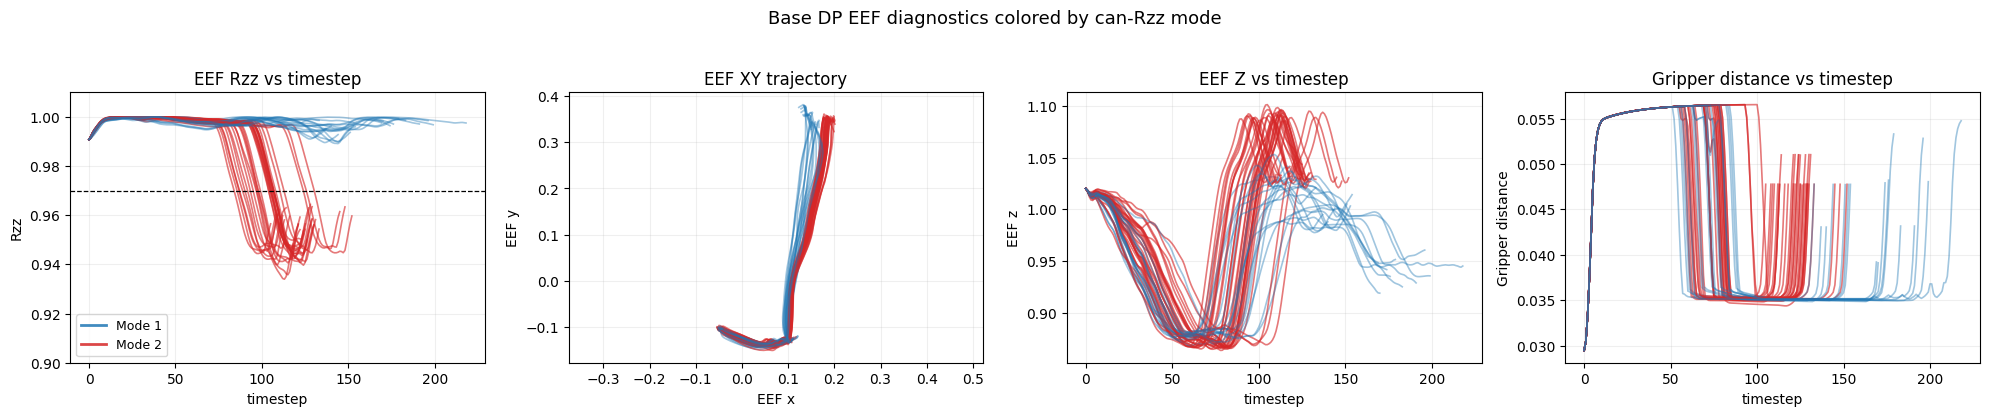

run root: /scratch/gilbreth/zoellner/diffusion_rollouts/can_rollouts/comparison/20260407_210830_v1_s1_50
method: dp_base | env: n16h300r60g1bYfYv1
classification: can Rzz, core window [0.00, 0.90], threshold 0.97, trigger >= 3 violations

Mode        N  Can Rzz(core)  EEF Rzz(core)  EEF Z(core)  Gripper(core)
------------------------------------------------------------------------------
1          17        0.9975        0.9979      0.9575        0.0443
2          33        0.9930        0.9936      0.9572        0.0481


In [8]:
# Base DP: EEF plots colored by can-Rzz mode classification.
# Four views: aligned EEF Rzz, EEF XY trajectory, EEF Z, and gripper distance.

from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

base_dir = Path("/scratch/gilbreth/zoellner/diffusion_rollouts/can_rollouts/comparison")
method_slug = "dp_base"
env_name = "n16h300r60g1bYfYv1"
seed_range = range(1, 51)
threshold = 0.97
core_start_fraction = 0.00
core_end_fraction = 0.90
violation_steps_for_mode2 = 3

# Reuse the current run if available; otherwise take the newest comparison run.
if "current_run_root" in globals():
    run_root = Path(current_run_root)
else:
    run_dirs = sorted([p for p in base_dir.iterdir() if p.is_dir()])
    if not run_dirs:
        raise RuntimeError("No comparison run directories found.")
    run_root = run_dirs[-1]

rows_path = run_root / method_slug / "rollout_rows.jsonl"
if not rows_path.exists():
    raise FileNotFoundError(f"Missing rows file: {rows_path}")

with rows_path.open("r", encoding="utf-8") as f:
    rows = [json.loads(line) for line in f if line.strip()]

seed_to_states = {}
seed_to_can_rzz = {}
seed_to_mode = {}

for r in rows:
    if r.get("init_name") != env_name:
        continue

    seed = int(r.get("seed", -1))
    if seed not in seed_range:
        continue

    npz_path = run_root / method_slug / f"{env_name}__seed_{seed:02d}" / "rollout_numeric.npz"
    if not npz_path.exists():
        continue

    data = np.load(npz_path)
    states = np.asarray(data["states"], dtype=np.float32)
    can_rzz = np.asarray(data["rzz_mujoco"], dtype=np.float32)

    seed_to_states[seed] = states
    seed_to_can_rzz[seed] = can_rzz

    n = len(can_rzz)
    i0 = max(0, min(n - 1, int(n * core_start_fraction)))
    i1 = min(n, max(i0 + 1, int(n * core_end_fraction)))
    can_rzz_core = can_rzz[i0:i1]
    violation_count = int(np.sum(can_rzz_core < threshold))
    seed_to_mode[seed] = 2 if violation_count >= violation_steps_for_mode2 else 1


def reconstruct_rotation_matrix_from_6d(rotation_6d: np.ndarray) -> np.ndarray:
    r1 = rotation_6d[:3]
    r2 = rotation_6d[3:6]

    r1_norm = r1 / (np.linalg.norm(r1) + 1e-8)
    r2_orth = r2 - np.dot(r1_norm, r2) * r1_norm
    r2_norm = r2_orth / (np.linalg.norm(r2_orth) + 1e-8)
    r3_norm = np.cross(r1_norm, r2_norm)

    return np.stack([r1_norm, r2_norm, r3_norm], axis=1)


def compute_eef_rzz(states: np.ndarray) -> np.ndarray:
    eef_q6d = np.asarray(states[:, 21:27], dtype=np.float32)
    eef_rzz = [reconstruct_rotation_matrix_from_6d(q6d)[2, 2] for q6d in eef_q6d]
    return -np.asarray(eef_rzz, dtype=np.float32)


def compute_gripper_distance(states: np.ndarray) -> np.ndarray:
    gripper_qpos = np.asarray(states[:, 27:29], dtype=np.float32)
    gripper_dist = np.linalg.norm(gripper_qpos, axis=1)
    return gripper_dist


mode_colors = {
    1: "#1f77b4",
    2: "#d62728",
}

fig, axes = plt.subplots(1, 4, figsize=(20, 4.2))
ax_rzz, ax_xy, ax_z, ax_gripper = axes

mode_stats = {
    1: {"can_rzz": [], "eef_rzz": [], "eef_z": [], "gripper_dist": []},
    2: {"can_rzz": [], "eef_rzz": [], "eef_z": [], "gripper_dist": []},
}

for seed in seed_range:
    states = seed_to_states.get(seed)
    can_rzz = seed_to_can_rzz.get(seed)
    mode = seed_to_mode.get(seed)
    if states is None or can_rzz is None or mode is None:
        continue

    eef_pos = np.asarray(states[:, 18:21], dtype=np.float32)
    eef_rzz = compute_eef_rzz(states)
    gripper_dist = compute_gripper_distance(states)
    color = mode_colors[mode]
    alpha = 0.42 if mode == 1 else 0.62

    ax_rzz.plot(eef_rzz, color=color, lw=1.2, alpha=alpha)
    ax_xy.plot(eef_pos[:, 0], eef_pos[:, 1], color=color, lw=1.2, alpha=alpha)
    ax_z.plot(eef_pos[:, 2], color=color, lw=1.2, alpha=alpha)
    ax_gripper.plot(gripper_dist, color=color, lw=1.2, alpha=alpha)

    n = len(can_rzz)
    i0 = max(0, min(n - 1, int(n * core_start_fraction)))
    i1 = min(n, max(i0 + 1, int(n * core_end_fraction)))
    mode_stats[mode]["can_rzz"].append(float(np.mean(can_rzz[i0:i1])))
    mode_stats[mode]["eef_rzz"].append(float(np.mean(eef_rzz[i0:i1])))
    mode_stats[mode]["eef_z"].append(float(np.mean(eef_pos[i0:i1, 2])))
    mode_stats[mode]["gripper_dist"].append(float(np.mean(gripper_dist[i0:i1])))

for ax in axes:
    ax.grid(alpha=0.2)

ax_rzz.axhline(threshold, color="black", linestyle="--", linewidth=0.9)
ax_rzz.set_title("EEF Rzz vs timestep")
ax_rzz.set_xlabel("timestep")
ax_rzz.set_ylabel("Rzz")
ax_rzz.set_ylim(0.90, 1.01)

ax_xy.set_title("EEF XY trajectory")
ax_xy.set_xlabel("EEF x")
ax_xy.set_ylabel("EEF y")
ax_xy.set_aspect("equal", adjustable="datalim")

ax_z.set_title("EEF Z vs timestep")
ax_z.set_xlabel("timestep")
ax_z.set_ylabel("EEF z")

ax_gripper.set_title("Gripper distance vs timestep")
ax_gripper.set_xlabel("timestep")
ax_gripper.set_ylabel("Gripper distance")

ax_rzz.plot([], [], color=mode_colors[1], lw=2.0, alpha=0.85, label="Mode 1")
ax_rzz.plot([], [], color=mode_colors[2], lw=2.0, alpha=0.85, label="Mode 2")
ax_rzz.legend(frameon=True, fontsize=9, loc="best")

fig.suptitle("Base DP EEF diagnostics colored by can-Rzz mode", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print(f"run root: {run_root}")
print(f"method: {method_slug} | env: {env_name}")
print(f"classification: can Rzz, core window [{core_start_fraction:.2f}, {core_end_fraction:.2f}], threshold {threshold:.2f}, trigger >= {violation_steps_for_mode2} violations")
print()
print(f"{'Mode':<8} {'N':>4} {'Can Rzz(core)':>14} {'EEF Rzz(core)':>14} {'EEF Z(core)':>12} {'Gripper(core)':>14}")
print("-" * 78)
for mode in [1, 2]:
    can_vals = mode_stats[mode]["can_rzz"]
    eef_rzz_vals = mode_stats[mode]["eef_rzz"]
    eef_z_vals = mode_stats[mode]["eef_z"]
    gripper_vals = mode_stats[mode]["gripper_dist"]
    print(
        f"{mode:<8} {len(can_vals):>4} "
        f"{(np.mean(can_vals) if can_vals else float('nan')):>13.4f} "
        f"{(np.mean(eef_rzz_vals) if eef_rzz_vals else float('nan')):>13.4f} "
        f"{(np.mean(eef_z_vals) if eef_z_vals else float('nan')):>11.4f} "
        f"{(np.mean(gripper_vals) if gripper_vals else float('nan')):>13.4f}"
    )

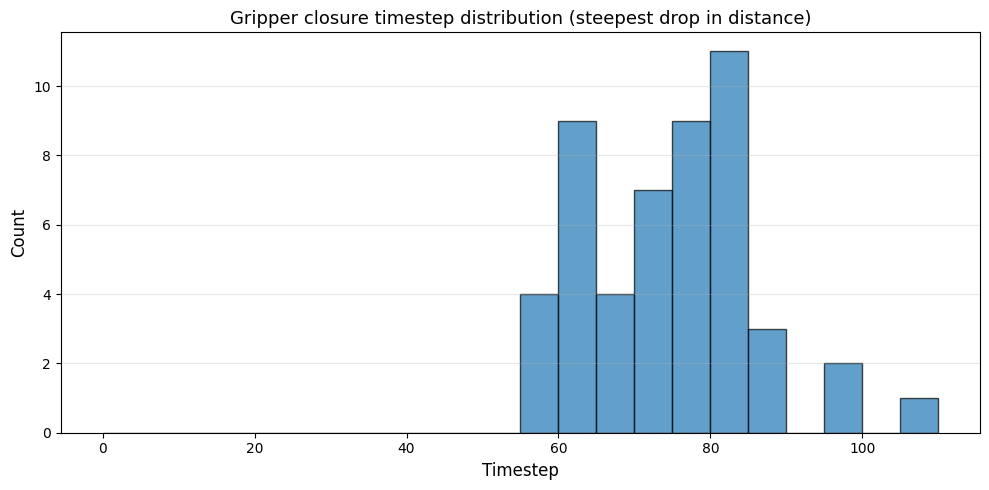

Gripper closure timesteps (steepest negative gradient):
  Total rollouts analyzed: 50
  Min: 55
  Mean: 74.34
  Median: 76
  Max: 105
  Std: 10.75
  All timesteps: [55, 57, 58, 59, 60, 61, 61, 62, 62, 63, 63, 63, 64, 66, 66, 67, 68, 71, 73, 73, 73, 73, 73, 74, 76, 76, 78, 78, 78, 78, 79, 79, 79, 80, 80, 81, 81, 81, 81, 81, 82, 82, 83, 83, 85, 86, 88, 96, 96, 105]

Gripper drop magnitudes (at closure timestep):
  Mean: -0.004616
  Min: -0.005022
  Max: -0.003793


In [10]:
# Gripper closure histogram: find timestep of sharpest drop in gripper distance.
# This is where the gripper closes from ~0.5 to ~0.35.

gripper_closure_timesteps = []
gripper_drop_magnitudes = []

for seed in seed_range:
    states = seed_to_states.get(seed)
    if states is None:
        continue

    gripper_qpos = np.asarray(states[:, 27:29], dtype=np.float32)
    gripper_dist = np.linalg.norm(gripper_qpos, axis=1)

    # Compute gradient (rate of change of distance)
    gradient = np.gradient(gripper_dist)
    
    n = len(gripper_dist)
    start_idx = max(0, 10)
    end_idx = min(n, n - 10) if n > 20 else n
    
    if start_idx < end_idx:
        # Find the timestep with the steepest drop (most negative gradient)
        gradient_window = gradient[start_idx:end_idx]
        local_steepest_idx = int(np.argmin(gradient_window))  # argmin finds most negative
        global_steepest_timestep = start_idx + local_steepest_idx
        
        gripper_closure_timesteps.append(global_steepest_timestep)
        gripper_drop_magnitudes.append(float(gradient[global_steepest_timestep]))

fig, ax = plt.subplots(figsize=(10, 5))
bins = np.arange(0, max(gripper_closure_timesteps) + 10, 5)
counts, edges, patches = ax.hist(gripper_closure_timesteps, bins=bins, edgecolor="black", alpha=0.7, color="#1f77b4")

ax.set_xlabel("Timestep", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Gripper closure timestep distribution (steepest drop in distance)", fontsize=13)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Gripper closure timesteps (steepest negative gradient):")
print(f"  Total rollouts analyzed: {len(gripper_closure_timesteps)}")
print(f"  Min: {np.min(gripper_closure_timesteps)}")
print(f"  Mean: {np.mean(gripper_closure_timesteps):.2f}")
print(f"  Median: {np.median(gripper_closure_timesteps):.0f}")
print(f"  Max: {np.max(gripper_closure_timesteps)}")
print(f"  Std: {np.std(gripper_closure_timesteps):.2f}")
print(f"  All timesteps: {sorted(gripper_closure_timesteps)}")
print()
print(f"Gripper drop magnitudes (at closure timestep):")
print(f"  Mean: {np.mean(gripper_drop_magnitudes):.6f}")
print(f"  Min: {np.min(gripper_drop_magnitudes):.6f}")
print(f"  Max: {np.max(gripper_drop_magnitudes):.6f}")

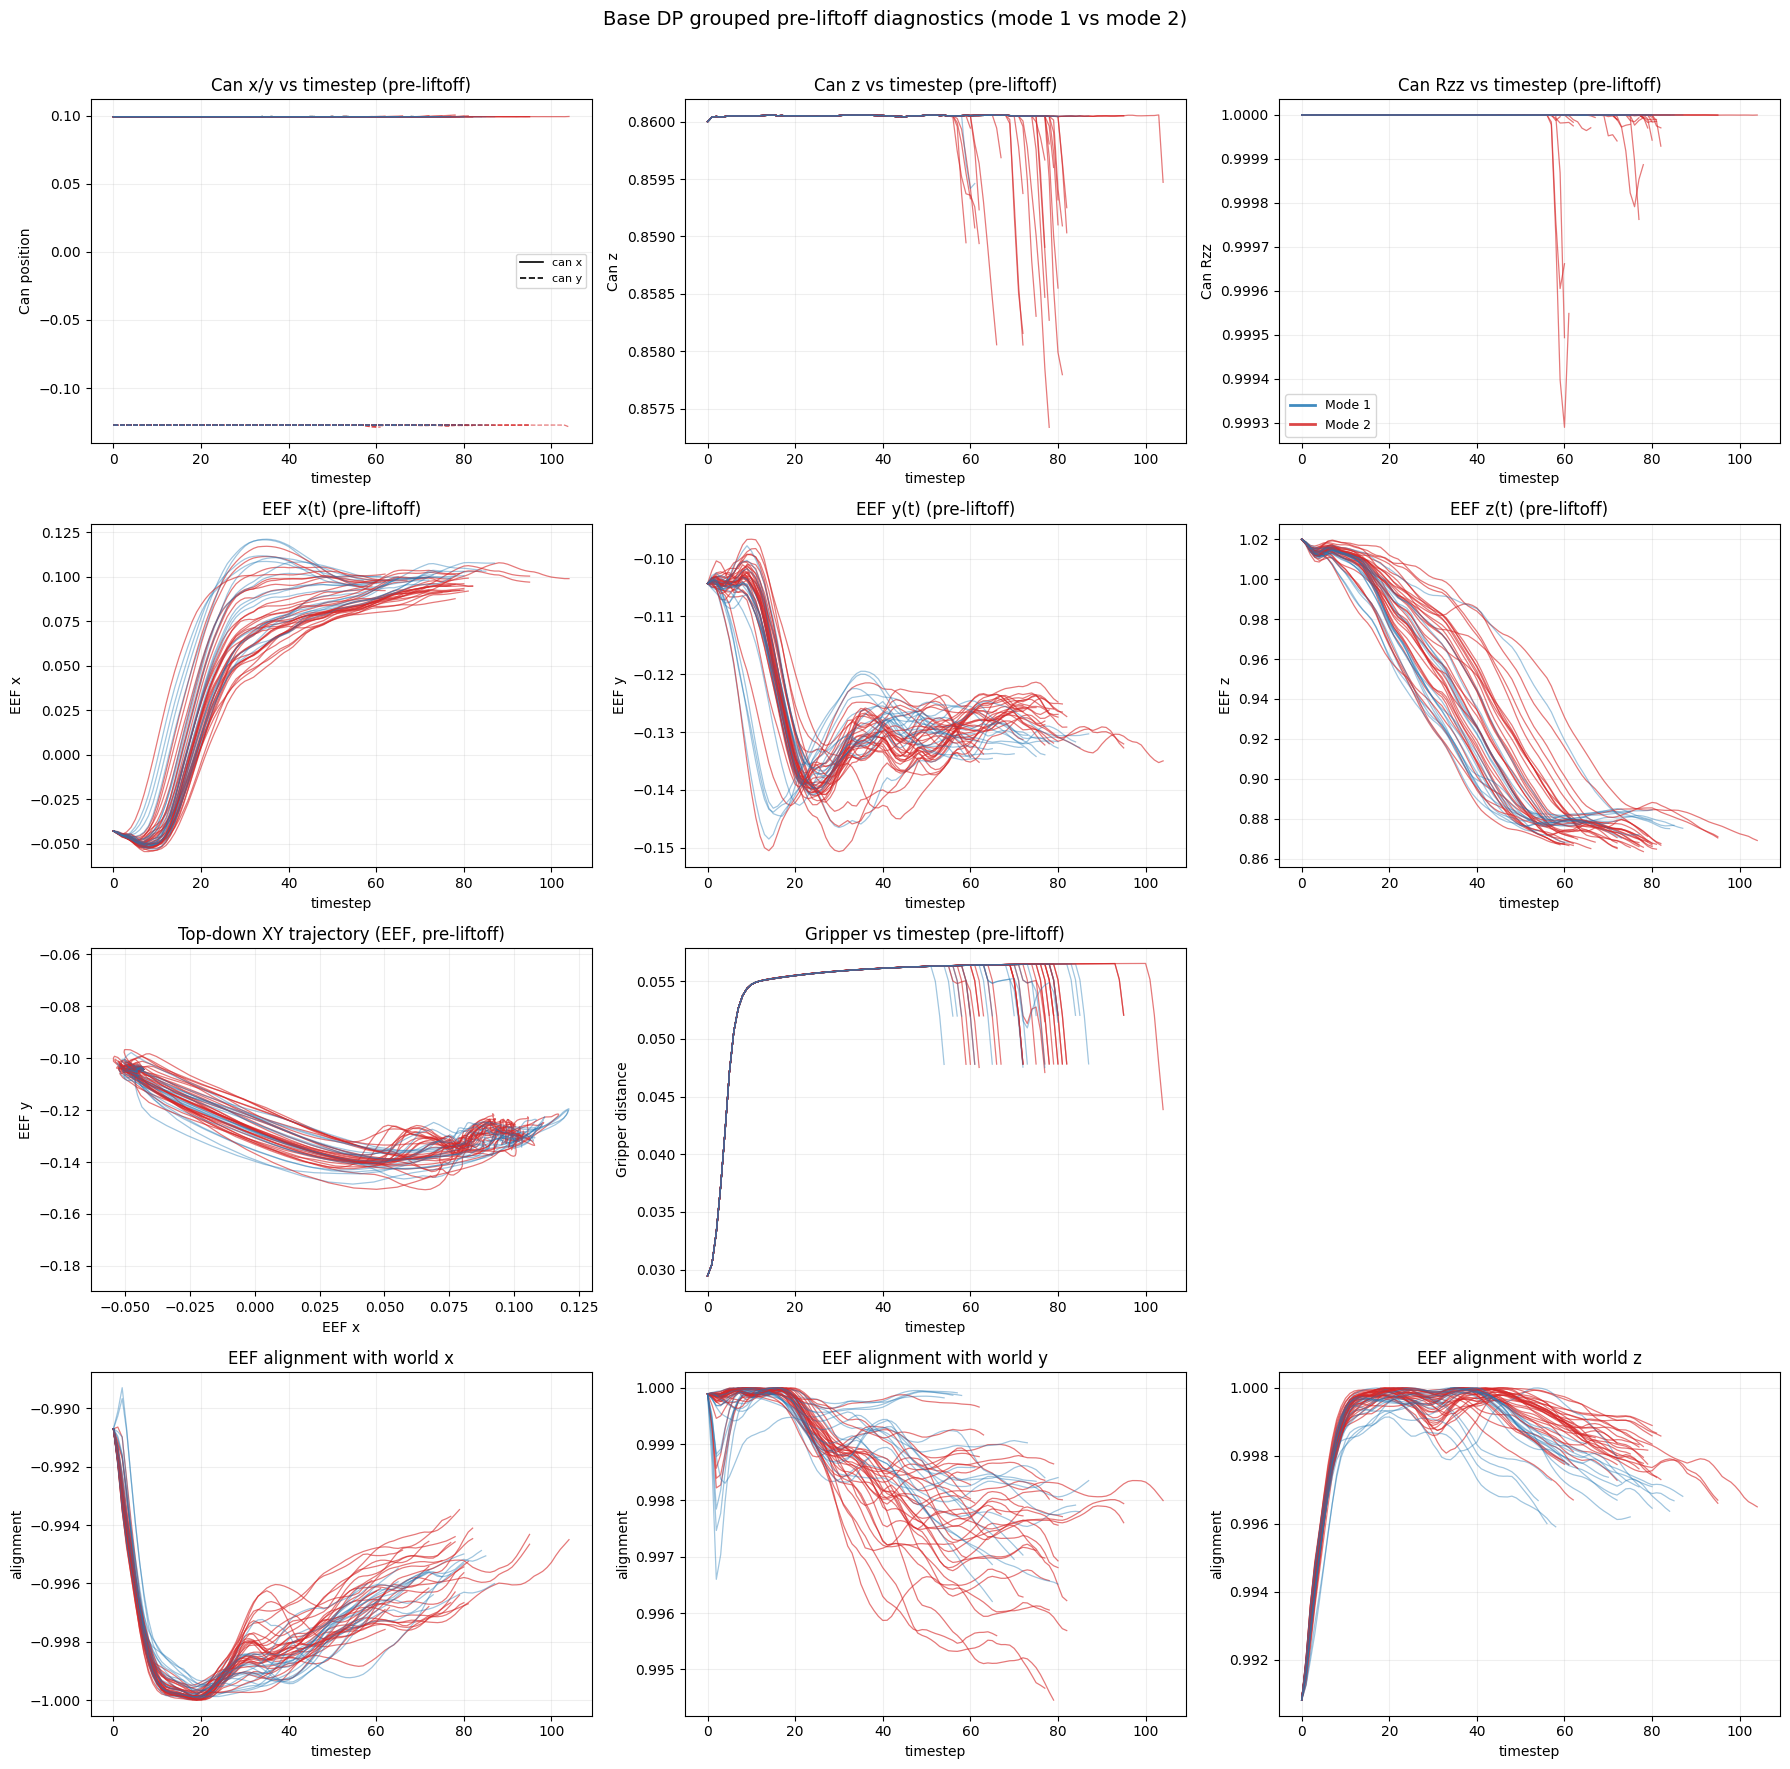

Pre-liftoff grouped statistics (all 50 seeds, truncated at closure):

Mode        N   Can Rzz(pre)  EEF AlignZ(pre)   EEF z(pre)   Gripper(pre)
------------------------------------------------------------------------------------
1          17        1.0000          0.9983      0.9393        0.0540
2          33        1.0000          0.9988      0.9427        0.0541


In [11]:
# Expanded pre-liftoff diagnostics grouped by mode (mode 1 / mode 2).
# Trajectories are truncated at the detected gripper-closure timestep.

fig, axes = plt.subplots(4, 3, figsize=(18, 18))

# Recompute DP mode assignment locally so this cell is robust to variable overwrites
# from other cells that may also define `seed_to_mode`.
dp_seed_to_mode = {}
for seed in seed_range:
    can_rzz_full = seed_to_can_rzz.get(seed)
    if can_rzz_full is None:
        continue

    n = len(can_rzz_full)
    i0 = max(0, min(n - 1, int(n * core_start_fraction)))
    i1 = min(n, max(i0 + 1, int(n * core_end_fraction)))
    can_rzz_core = can_rzz_full[i0:i1]
    violation_count = int(np.sum(can_rzz_core < threshold))
    dp_seed_to_mode[seed] = 2 if violation_count >= violation_steps_for_mode2 else 1

mode_stats_pre = {
    1: {"can_rzz": [], "eef_align_z": [], "eef_z": [], "gripper_dist": []},
    2: {"can_rzz": [], "eef_align_z": [], "eef_z": [], "gripper_dist": []},
}

# Map seed to its closure timestep from the previous cell
seed_to_closure_idx = {}
for i, seed in enumerate(seed_range):
    if i < len(gripper_closure_timesteps):
        seed_to_closure_idx[seed] = gripper_closure_timesteps[i]

for seed in seed_range:
    states = seed_to_states.get(seed)
    can_rzz = seed_to_can_rzz.get(seed)
    mode = dp_seed_to_mode.get(seed)
    closure_idx = seed_to_closure_idx.get(seed)

    if states is None or can_rzz is None or mode is None or closure_idx is None:
        continue

    # Truncate each rollout to the pre-liftoff interval
    states_pre = states[:closure_idx]
    can_rzz_pre = can_rzz[:closure_idx]

    can_pos = np.asarray(states_pre[:, 9:12], dtype=np.float32)      # can x,y,z
    eef_pos = np.asarray(states_pre[:, 18:21], dtype=np.float32)     # eef x,y,z
    eef_q6d = np.asarray(states_pre[:, 21:27], dtype=np.float32)     # eef rotation in 6D
    gripper_dist = compute_gripper_distance(states_pre)

    # EEF world-axis alignment metrics (same sign convention as existing z alignment)
    eef_align_x = []
    eef_align_y = []
    eef_align_z = []
    for q6d in eef_q6d:
        R = reconstruct_rotation_matrix_from_6d(q6d)
        eef_align_x.append(-R[0, 0])
        eef_align_y.append(-R[1, 1])
        eef_align_z.append(-R[2, 2])
    eef_align_x = np.asarray(eef_align_x, dtype=np.float32)
    eef_align_y = np.asarray(eef_align_y, dtype=np.float32)
    eef_align_z = np.asarray(eef_align_z, dtype=np.float32)

    color = mode_colors[mode]
    alpha = 0.42 if mode == 1 else 0.62
    lw = 0.9

    # Row 1: can metrics
    axes[0, 0].plot(can_pos[:, 0], color=color, lw=lw, alpha=alpha, linestyle="-", label=None)
    axes[0, 0].plot(can_pos[:, 1], color=color, lw=lw, alpha=alpha, linestyle="--", label=None)
    axes[0, 1].plot(can_pos[:, 2], color=color, lw=lw, alpha=alpha)
    axes[0, 2].plot(can_rzz_pre, color=color, lw=lw, alpha=alpha)

    # Row 2: eef xyz over time
    axes[1, 0].plot(eef_pos[:, 0], color=color, lw=lw, alpha=alpha)
    axes[1, 1].plot(eef_pos[:, 1], color=color, lw=lw, alpha=alpha)
    axes[1, 2].plot(eef_pos[:, 2], color=color, lw=lw, alpha=alpha)

    # Row 3: top-down trajectory + gripper vs time + empty
    axes[2, 0].plot(eef_pos[:, 0], eef_pos[:, 1], color=color, lw=lw, alpha=alpha)
    axes[2, 1].plot(gripper_dist, color=color, lw=lw, alpha=alpha)

    # Row 4: eef alignment with world axes
    axes[3, 0].plot(eef_align_x, color=color, lw=lw, alpha=alpha)
    axes[3, 1].plot(eef_align_y, color=color, lw=lw, alpha=alpha)
    axes[3, 2].plot(eef_align_z, color=color, lw=lw, alpha=alpha)

    mode_stats_pre[mode]["can_rzz"].append(float(np.mean(can_rzz_pre)))
    mode_stats_pre[mode]["eef_align_z"].append(float(np.mean(eef_align_z)))
    mode_stats_pre[mode]["eef_z"].append(float(np.mean(eef_pos[:, 2])))
    mode_stats_pre[mode]["gripper_dist"].append(float(np.mean(gripper_dist)))

# Shared styling
for ax in axes.flatten():
    ax.grid(alpha=0.2)

# Row 1 titles
axes[0, 0].set_title("Can x/y vs timestep (pre-liftoff)")
axes[0, 0].set_xlabel("timestep")
axes[0, 0].set_ylabel("Can position")
axes[0, 0].plot([], [], color="black", linestyle="-", lw=1.2, label="can x")
axes[0, 0].plot([], [], color="black", linestyle="--", lw=1.2, label="can y")

axes[0, 1].set_title("Can z vs timestep (pre-liftoff)")
axes[0, 1].set_xlabel("timestep")
axes[0, 1].set_ylabel("Can z")

axes[0, 2].set_title("Can Rzz vs timestep (pre-liftoff)")
axes[0, 2].set_xlabel("timestep")
axes[0, 2].set_ylabel("Can Rzz")

# Row 2 titles
axes[1, 0].set_title("EEF x(t) (pre-liftoff)")
axes[1, 0].set_xlabel("timestep")
axes[1, 0].set_ylabel("EEF x")

axes[1, 1].set_title("EEF y(t) (pre-liftoff)")
axes[1, 1].set_xlabel("timestep")
axes[1, 1].set_ylabel("EEF y")

axes[1, 2].set_title("EEF z(t) (pre-liftoff)")
axes[1, 2].set_xlabel("timestep")
axes[1, 2].set_ylabel("EEF z")

# Row 3 titles
axes[2, 0].set_title("Top-down XY trajectory (EEF, pre-liftoff)")
axes[2, 0].set_xlabel("EEF x")
axes[2, 0].set_ylabel("EEF y")
axes[2, 0].set_aspect("equal", adjustable="datalim")

axes[2, 1].set_title("Gripper vs timestep (pre-liftoff)")
axes[2, 1].set_xlabel("timestep")
axes[2, 1].set_ylabel("Gripper distance")

axes[2, 2].axis("off")

# Row 4 titles
axes[3, 0].set_title("EEF alignment with world x")
axes[3, 0].set_xlabel("timestep")
axes[3, 0].set_ylabel("alignment")

axes[3, 1].set_title("EEF alignment with world y")
axes[3, 1].set_xlabel("timestep")
axes[3, 1].set_ylabel("alignment")

axes[3, 2].set_title("EEF alignment with world z")
axes[3, 2].set_xlabel("timestep")
axes[3, 2].set_ylabel("alignment")

# Mode legend handles
axes[0, 2].plot([], [], color=mode_colors[1], lw=2.0, alpha=0.85, label="Mode 1")
axes[0, 2].plot([], [], color=mode_colors[2], lw=2.0, alpha=0.85, label="Mode 2")
axes[0, 2].legend(frameon=True, fontsize=9, loc="best")
axes[0, 0].legend(frameon=True, fontsize=8, loc="best")

fig.suptitle("Base DP grouped pre-liftoff diagnostics (mode 1 vs mode 2)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

print(f"Pre-liftoff grouped statistics (all {len(seed_range)} seeds, truncated at closure):")
print()
print(f"{'Mode':<8} {'N':>4} {'Can Rzz(pre)':>14} {'EEF AlignZ(pre)':>16} {'EEF z(pre)':>12} {'Gripper(pre)':>14}")
print("-" * 84)
for mode in [1, 2]:
    can_vals = mode_stats_pre[mode]["can_rzz"]
    alignz_vals = mode_stats_pre[mode]["eef_align_z"]
    eef_z_vals = mode_stats_pre[mode]["eef_z"]
    gripper_vals = mode_stats_pre[mode]["gripper_dist"]
    print(
        f"{mode:<8} {len(can_vals):>4} "
        f"{(np.mean(can_vals) if can_vals else float('nan')):>13.4f} "
        f"{(np.mean(alignz_vals) if alignz_vals else float('nan')):>15.4f} "
        f"{(np.mean(eef_z_vals) if eef_z_vals else float('nan')):>11.4f} "
        f"{(np.mean(gripper_vals) if gripper_vals else float('nan')):>13.4f}"
    )

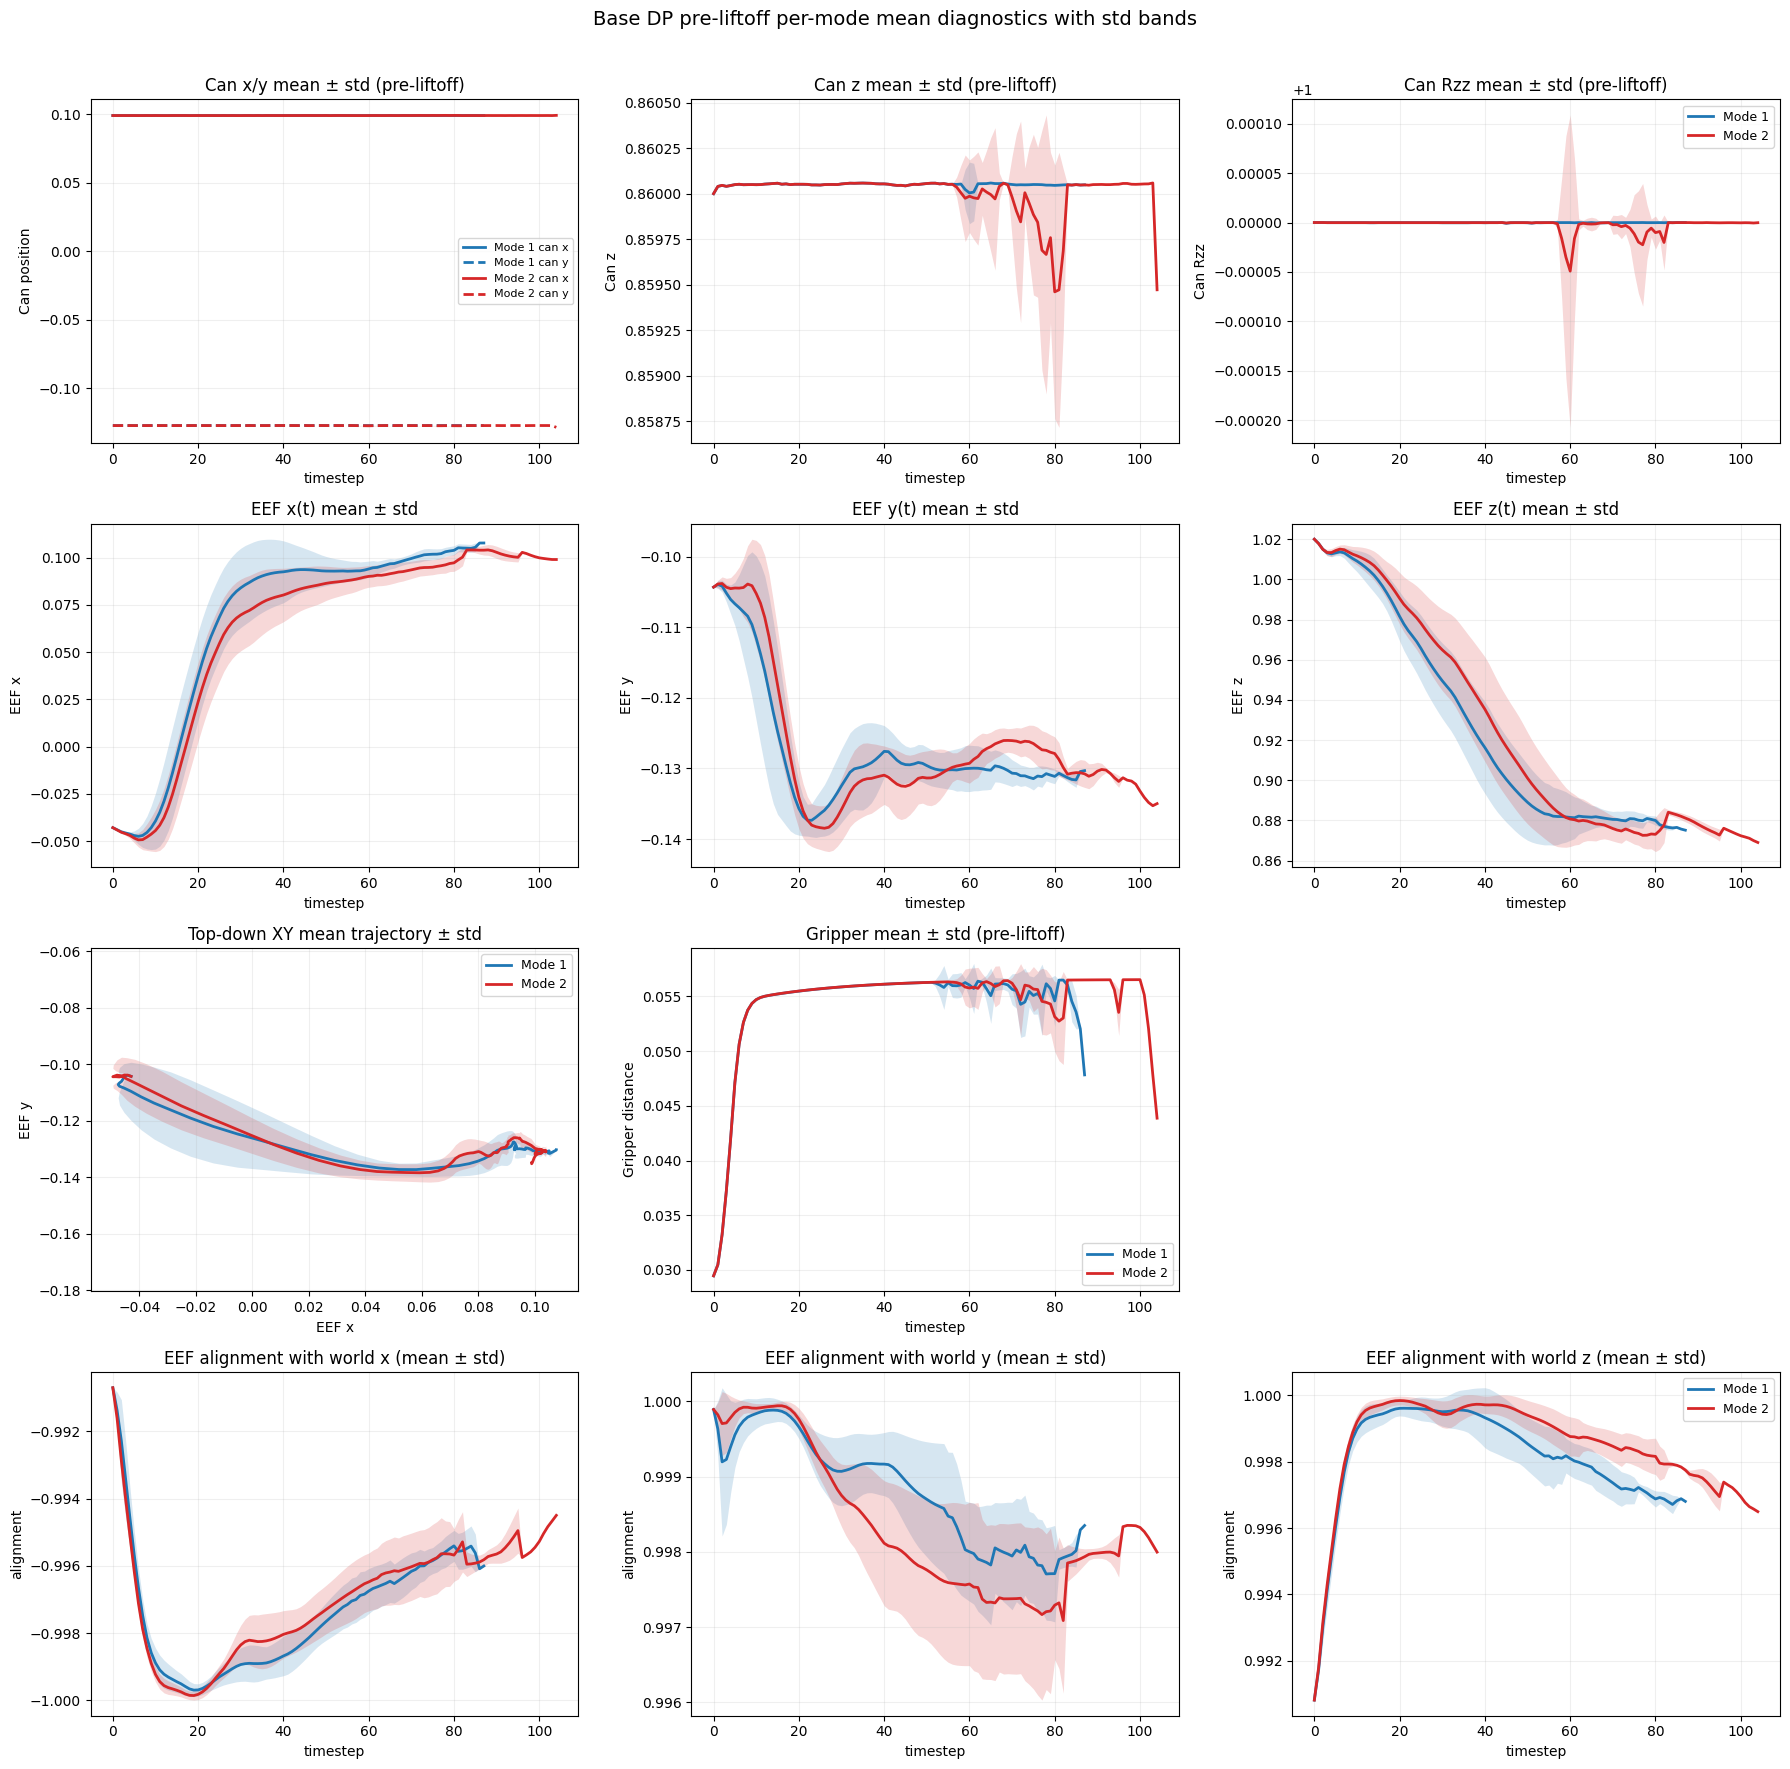

In [12]:
# Per-mode mean ± std diagnostics (pre-liftoff) for all panels.

fig, axes = plt.subplots(4, 3, figsize=(18, 18))

# Recompute DP mode assignment locally for robustness.
dp_seed_to_mode = {}
for seed in seed_range:
    can_rzz_full = seed_to_can_rzz.get(seed)
    if can_rzz_full is None:
        continue
    n = len(can_rzz_full)
    i0 = max(0, min(n - 1, int(n * core_start_fraction)))
    i1 = min(n, max(i0 + 1, int(n * core_end_fraction)))
    can_rzz_core = can_rzz_full[i0:i1]
    violation_count = int(np.sum(can_rzz_core < threshold))
    dp_seed_to_mode[seed] = 2 if violation_count >= violation_steps_for_mode2 else 1

# Map seed -> closure timestep from Cell 11 output.
seed_to_closure_idx = {}
for i, seed in enumerate(seed_range):
    if i < len(gripper_closure_timesteps):
        seed_to_closure_idx[seed] = gripper_closure_timesteps[i]

metric_keys = [
    "can_x", "can_y", "can_z", "can_rzz",
    "eef_x", "eef_y", "eef_z", "gripper",
    "align_x", "align_y", "align_z",
]

mode_to_series = {
    1: {k: [] for k in metric_keys},
    2: {k: [] for k in metric_keys},
}

for seed in seed_range:
    states = seed_to_states.get(seed)
    can_rzz = seed_to_can_rzz.get(seed)
    mode = dp_seed_to_mode.get(seed)
    closure_idx = seed_to_closure_idx.get(seed)

    if states is None or can_rzz is None or mode is None or closure_idx is None:
        continue

    states_pre = states[:closure_idx]
    can_rzz_pre = can_rzz[:closure_idx]

    can_pos = np.asarray(states_pre[:, 9:12], dtype=np.float32)
    eef_pos = np.asarray(states_pre[:, 18:21], dtype=np.float32)
    eef_q6d = np.asarray(states_pre[:, 21:27], dtype=np.float32)
    gripper_dist = compute_gripper_distance(states_pre)

    align_x, align_y, align_z = [], [], []
    for q6d in eef_q6d:
        R = reconstruct_rotation_matrix_from_6d(q6d)
        align_x.append(-R[0, 0])
        align_y.append(-R[1, 1])
        align_z.append(-R[2, 2])

    mode_to_series[mode]["can_x"].append(can_pos[:, 0])
    mode_to_series[mode]["can_y"].append(can_pos[:, 1])
    mode_to_series[mode]["can_z"].append(can_pos[:, 2])
    mode_to_series[mode]["can_rzz"].append(can_rzz_pre)

    mode_to_series[mode]["eef_x"].append(eef_pos[:, 0])
    mode_to_series[mode]["eef_y"].append(eef_pos[:, 1])
    mode_to_series[mode]["eef_z"].append(eef_pos[:, 2])
    mode_to_series[mode]["gripper"].append(gripper_dist)

    mode_to_series[mode]["align_x"].append(np.asarray(align_x, dtype=np.float32))
    mode_to_series[mode]["align_y"].append(np.asarray(align_y, dtype=np.float32))
    mode_to_series[mode]["align_z"].append(np.asarray(align_z, dtype=np.float32))


def _stack_nan(series_list):
    max_len = max(len(s) for s in series_list)
    stacked = np.full((len(series_list), max_len), np.nan, dtype=np.float32)
    for i, s in enumerate(series_list):
        stacked[i, :len(s)] = s
    return stacked


def _mean_std(series_list):
    if not series_list:
        return None, None, None
    stacked = _stack_nan(series_list)
    mean = np.nanmean(stacked, axis=0)
    std = np.nanstd(stacked, axis=0)
    t = np.arange(stacked.shape[1])
    return t, mean, std


def _plot_mean_std(ax, t, mean, std, color, label, lw=2.0, fill_alpha=0.18, ls="-"):
    ax.plot(t, mean, color=color, lw=lw, linestyle=ls, label=label)
    ax.fill_between(t, mean - std, mean + std, color=color, alpha=fill_alpha, linewidth=0)

# Row 1: can x/y, can z, can rzz
for mode in [1, 2]:
    color = mode_colors[mode]
    t, m, s = _mean_std(mode_to_series[mode]["can_x"])
    if t is not None:
        _plot_mean_std(axes[0, 0], t, m, s, color, f"Mode {mode} can x", ls="-")
    t, m, s = _mean_std(mode_to_series[mode]["can_y"])
    if t is not None:
        _plot_mean_std(axes[0, 0], t, m, s, color, f"Mode {mode} can y", ls="--")

    t, m, s = _mean_std(mode_to_series[mode]["can_z"])
    if t is not None:
        _plot_mean_std(axes[0, 1], t, m, s, color, f"Mode {mode}")

    t, m, s = _mean_std(mode_to_series[mode]["can_rzz"])
    if t is not None:
        _plot_mean_std(axes[0, 2], t, m, s, color, f"Mode {mode}")

# Row 2: eef x,y,z
for mode in [1, 2]:
    color = mode_colors[mode]
    for col, key in enumerate(["eef_x", "eef_y", "eef_z"]):
        t, m, s = _mean_std(mode_to_series[mode][key])
        if t is not None:
            _plot_mean_std(axes[1, col], t, m, s, color, f"Mode {mode}")

# Row 3: top-down mean trajectory + gripper + empty
for mode in [1, 2]:
    color = mode_colors[mode]
    tx, mx, sx = _mean_std(mode_to_series[mode]["eef_x"])
    ty, my, sy = _mean_std(mode_to_series[mode]["eef_y"])
    if tx is not None and ty is not None:
        L = min(len(mx), len(my))
        axes[2, 0].plot(mx[:L], my[:L], color=color, lw=2.0, label=f"Mode {mode}")
        axes[2, 0].fill_between(mx[:L], my[:L] - sy[:L], my[:L] + sy[:L], color=color, alpha=0.18, linewidth=0)

    t, m, s = _mean_std(mode_to_series[mode]["gripper"])
    if t is not None:
        _plot_mean_std(axes[2, 1], t, m, s, color, f"Mode {mode}")

axes[2, 2].axis("off")

# Row 4: alignment x,y,z
for mode in [1, 2]:
    color = mode_colors[mode]
    for col, key in enumerate(["align_x", "align_y", "align_z"]):
        t, m, s = _mean_std(mode_to_series[mode][key])
        if t is not None:
            _plot_mean_std(axes[3, col], t, m, s, color, f"Mode {mode}")

# Titles and labels
axes[0, 0].set_title("Can x/y mean ± std (pre-liftoff)")
axes[0, 0].set_xlabel("timestep")
axes[0, 0].set_ylabel("Can position")

axes[0, 1].set_title("Can z mean ± std (pre-liftoff)")
axes[0, 1].set_xlabel("timestep")
axes[0, 1].set_ylabel("Can z")

axes[0, 2].set_title("Can Rzz mean ± std (pre-liftoff)")
axes[0, 2].set_xlabel("timestep")
axes[0, 2].set_ylabel("Can Rzz")

axes[1, 0].set_title("EEF x(t) mean ± std")
axes[1, 0].set_xlabel("timestep")
axes[1, 0].set_ylabel("EEF x")

axes[1, 1].set_title("EEF y(t) mean ± std")
axes[1, 1].set_xlabel("timestep")
axes[1, 1].set_ylabel("EEF y")

axes[1, 2].set_title("EEF z(t) mean ± std")
axes[1, 2].set_xlabel("timestep")
axes[1, 2].set_ylabel("EEF z")

axes[2, 0].set_title("Top-down XY mean trajectory ± std")
axes[2, 0].set_xlabel("EEF x")
axes[2, 0].set_ylabel("EEF y")
axes[2, 0].set_aspect("equal", adjustable="datalim")

axes[2, 1].set_title("Gripper mean ± std (pre-liftoff)")
axes[2, 1].set_xlabel("timestep")
axes[2, 1].set_ylabel("Gripper distance")

axes[3, 0].set_title("EEF alignment with world x (mean ± std)")
axes[3, 0].set_xlabel("timestep")
axes[3, 0].set_ylabel("alignment")

axes[3, 1].set_title("EEF alignment with world y (mean ± std)")
axes[3, 1].set_xlabel("timestep")
axes[3, 1].set_ylabel("alignment")

axes[3, 2].set_title("EEF alignment with world z (mean ± std)")
axes[3, 2].set_xlabel("timestep")
axes[3, 2].set_ylabel("alignment")

for ax in axes.flatten():
    ax.grid(alpha=0.2)

axes[0, 0].legend(frameon=True, fontsize=8, loc="best")
axes[0, 2].legend(frameon=True, fontsize=9, loc="best")
axes[2, 0].legend(frameon=True, fontsize=9, loc="best")
axes[2, 1].legend(frameon=True, fontsize=9, loc="best")
axes[3, 2].legend(frameon=True, fontsize=9, loc="best")

fig.suptitle("Base DP pre-liftoff per-mode mean diagnostics with std bands", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [14]:
# Build pre-drop state index set: index just before gripper closure drop begins.
# Also compare to final pre-liftoff index (closure_idx - 1) for sanity.

pre_drop_indices = {}
pre_liftoff_last_indices = {}
index_deltas = {}

# Small threshold to ignore tiny numerical jitter
neg_eps = 1e-5

for seed in seed_range:
    states = seed_to_states.get(seed)
    if states is None:
        continue

    gripper_qpos = np.asarray(states[:, 27:29], dtype=np.float32)
    gripper_dist = np.linalg.norm(gripper_qpos, axis=1)
    n = len(gripper_dist)

    # Recompute closure timestep robustly (same rule as Cell 11)
    gradient = np.gradient(gripper_dist)
    start_idx = max(0, 10)
    end_idx = min(n, n - 10) if n > 20 else n
    if not (start_idx < end_idx):
        continue

    gradient_window = gradient[start_idx:end_idx]
    closure_idx = start_idx + int(np.argmin(gradient_window))

    # Final pre-liftoff index used by truncation states[:closure_idx]
    final_pre_liftoff_idx = max(0, closure_idx - 1)

    # Find the FIRST decrease that leads into the closure event, searching backwards
    # from closure_idx in a local window.
    diff = np.diff(gripper_dist)  # diff[t] = dist[t+1] - dist[t]

    lookback = 40
    local_start = max(0, closure_idx - lookback)
    local_end = min(len(diff) - 1, closure_idx)

    # Candidate decrease points in local window
    dec_candidates = [t for t in range(local_start, local_end + 1) if diff[t] < -neg_eps]

    if dec_candidates:
        # First decreasing index in this local closure window
        pre_drop_idx = int(dec_candidates[0])
    else:
        # Fallback: if no clear decrease found, use final pre-liftoff index
        pre_drop_idx = int(final_pre_liftoff_idx)

    pre_drop_indices[seed] = pre_drop_idx
    pre_liftoff_last_indices[seed] = int(final_pre_liftoff_idx)
    index_deltas[seed] = int(pre_drop_idx - final_pre_liftoff_idx)

# Print per-seed indices
sorted_seeds = sorted(pre_drop_indices.keys())

print("Pre-drop indices per seed (index before closure drop starts):")
print([pre_drop_indices[s] for s in sorted_seeds])
print()

print("Final pre-liftoff indices per seed (closure_idx - 1):")
print([pre_liftoff_last_indices[s] for s in sorted_seeds])
print()

print("Delta = pre_drop_idx - final_pre_liftoff_idx (should be 0 or negative/small):")
print([index_deltas[s] for s in sorted_seeds])
print()

# Sanity summary
all_deltas = np.asarray([index_deltas[s] for s in sorted_seeds], dtype=np.int32)
print(f"Seeds analyzed: {len(sorted_seeds)}")
print(f"Delta min / mean / max: {all_deltas.min()} / {all_deltas.mean():.2f} / {all_deltas.max()}")
print(f"Count exact match (delta=0): {int(np.sum(all_deltas == 0))}")
print(f"Count earlier than final pre-liftoff (delta<0): {int(np.sum(all_deltas < 0))}")
print(f"Count later than final pre-liftoff (delta>0): {int(np.sum(all_deltas > 0))}")

# Additional sanity check: inspect gripper distance at [prev, idx, next] around pre_drop_idx.
# Expectation: prev is similar or slightly smaller than idx; next should be smaller than idx.
neighbor_triplets = {}
prev_ok_count = 0
next_ok_count = 0

# Tolerance for "same/slightly smaller" on previous sample.
prev_tol = 2e-3

print()
print("Gripper distance sanity around pre-drop index [prev, idx, next]:")
for seed in sorted_seeds:
    states = seed_to_states.get(seed)
    if states is None:
        continue

    idx = int(pre_drop_indices[seed])
    gripper_qpos = np.asarray(states[:, 27:29], dtype=np.float32)
    gripper_dist = np.linalg.norm(gripper_qpos, axis=1)

    prev_idx = max(0, idx - 1)
    next_idx = min(len(gripper_dist) - 1, idx + 1)

    d_prev = float(gripper_dist[prev_idx])
    d_idx = float(gripper_dist[idx])
    d_next = float(gripper_dist[next_idx])

    # previous should be same or slightly smaller
    prev_ok = bool(d_prev <= d_idx + prev_tol)
    # next should definitely be smaller
    next_ok = bool(d_next < d_idx - neg_eps)

    prev_ok_count += int(prev_ok)
    next_ok_count += int(next_ok)

    neighbor_triplets[seed] = {
        "prev_idx": prev_idx,
        "idx": idx,
        "next_idx": next_idx,
        "d_prev": d_prev,
        "d_idx": d_idx,
        "d_next": d_next,
        "prev_ok": prev_ok,
        "next_ok": next_ok,
    }

    print(
        f"seed {seed:02d}: idx [{prev_idx:3d}, {idx:3d}, {next_idx:3d}] | "
        f"dist [{d_prev:.6f}, {d_idx:.6f}, {d_next:.6f}] | "
        f"prev_ok={prev_ok} next_ok={next_ok}"
    )

print()
print(f"prev_ok: {prev_ok_count}/{len(sorted_seeds)}")
print(f"next_ok: {next_ok_count}/{len(sorted_seeds)}")

# Optional dataset object: state vectors just before closure drop starts
pre_drop_state_dataset = {
    seed: np.asarray(seed_to_states[seed][idx], dtype=np.float32)
    for seed, idx in pre_drop_indices.items()
    if seed in seed_to_states and idx < len(seed_to_states[seed])
}

print(f"Saved pre-drop state vectors: {len(pre_drop_state_dataset)}")

Pre-drop indices per seed (index before closure drop starts):
[78, 82, 69, 78, 75, 100, 69, 55, 77, 69, 79, 70, 77, 72, 58, 56, 93, 79, 76, 76, 57, 78, 71, 60, 54, 70, 55, 75, 83, 63, 58, 60, 69, 58, 68, 74, 63, 64, 84, 63, 93, 63, 56, 51, 62, 77, 61, 78, 73, 71]

Final pre-liftoff indices per seed (closure_idx - 1):
[81, 84, 72, 80, 78, 104, 72, 57, 80, 72, 82, 77, 80, 75, 60, 59, 95, 82, 79, 78, 60, 81, 77, 62, 56, 73, 62, 78, 85, 80, 61, 62, 72, 61, 70, 77, 66, 67, 87, 72, 95, 65, 58, 54, 65, 79, 63, 80, 75, 77]

Delta = pre_drop_idx - final_pre_liftoff_idx (should be 0 or negative/small):
[-3, -2, -3, -2, -3, -4, -3, -2, -3, -3, -3, -7, -3, -3, -2, -3, -2, -3, -3, -2, -3, -3, -6, -2, -2, -3, -7, -3, -2, -17, -3, -2, -3, -3, -2, -3, -3, -3, -3, -9, -2, -2, -2, -3, -3, -2, -2, -2, -2, -6]

Seeds analyzed: 50
Delta min / mean / max: -17 / -3.34 / -2
Count exact match (delta=0): 0
Count earlier than final pre-liftoff (delta<0): 50
Count later than final pre-liftoff (delta>0): 0

Grippe

X shape: (50, 29)
y shape: (50,)
mode1 count (y=0): 17
mode2 count (y=1): 33
explained_variance_ratio_: [0.37907812 0.22751321]
cumulative explained variance (2 PCs): 0.6065913438796997


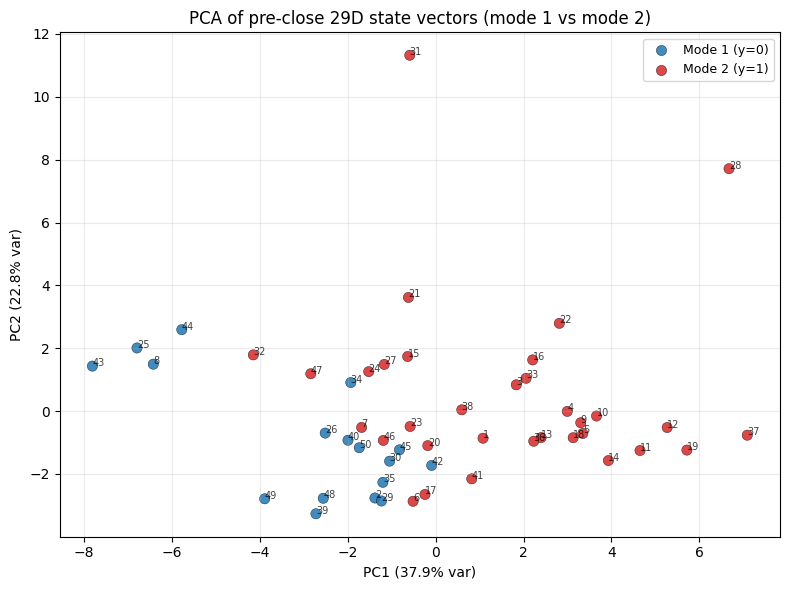


Top loading dimensions for PC1 (by absolute value):
  dim 07: loading=+0.2802
  dim 24: loading=+0.2801
  dim 04: loading=+0.2799
  dim 03: loading=-0.2761
  dim 22: loading=+0.2756
  dim 06: loading=+0.2744
  dim 25: loading=+0.2643
  dim 01: loading=+0.2240

Top loading dimensions for PC2 (by absolute value):
  dim 13: loading=+0.3465
  dim 15: loading=-0.3428
  dim 10: loading=-0.3117
  dim 12: loading=+0.3105
  dim 14: loading=-0.2889
  dim 16: loading=+0.2810
  dim 28: loading=+0.2435
  dim 17: loading=+0.2414


In [15]:
# PCA on pre-close state vectors: do mode 1 / mode 2 separate in 2D?

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Recompute DP mode assignment locally for robustness (same rule as earlier cells).
dp_seed_to_mode = {}
for seed in seed_range:
    can_rzz_full = seed_to_can_rzz.get(seed)
    if can_rzz_full is None:
        continue
    n = len(can_rzz_full)
    i0 = max(0, min(n - 1, int(n * core_start_fraction)))
    i1 = min(n, max(i0 + 1, int(n * core_end_fraction)))
    can_rzz_core = can_rzz_full[i0:i1]
    violation_count = int(np.sum(can_rzz_core < threshold))
    dp_seed_to_mode[seed] = 2 if violation_count >= violation_steps_for_mode2 else 1

# Collect data: X shape (N, 29), y shape (N,)
sorted_seeds = sorted(pre_drop_state_dataset.keys())
X = np.asarray([pre_drop_state_dataset[s] for s in sorted_seeds], dtype=np.float32)
y = np.asarray([0 if dp_seed_to_mode.get(s, 1) == 1 else 1 for s in sorted_seeds], dtype=np.int32)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"mode1 count (y=0): {int(np.sum(y == 0))}")
print(f"mode2 count (y=1): {int(np.sum(y == 1))}")

if X.ndim != 2 or X.shape[1] != 29:
    raise RuntimeError(f"Expected X to have shape (N, 29), got {X.shape}")

# Standardize features (z-score per dimension).
mu = X.mean(axis=0, keepdims=True)
sigma = X.std(axis=0, keepdims=True)
sigma_safe = np.where(sigma < 1e-8, 1.0, sigma)
X_std = (X - mu) / sigma_safe

# PCA to 2D
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_std)

print("explained_variance_ratio_:", pca.explained_variance_ratio_)
print("cumulative explained variance (2 PCs):", float(np.sum(pca.explained_variance_ratio_)))

# Scatter plot
fig, ax = plt.subplots(figsize=(8, 6))
colors = np.where(y == 0, "#1f77b4", "#d62728")
ax.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, s=55, alpha=0.85, edgecolor="k", linewidth=0.3)

# Optional annotation with rollout seed
for i, seed in enumerate(sorted_seeds):
    ax.annotate(str(seed), (X_pca[i, 0], X_pca[i, 1]), fontsize=7, alpha=0.75)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var)")
ax.set_title("PCA of pre-close 29D state vectors (mode 1 vs mode 2)")
ax.grid(alpha=0.25)

# Legend handles
ax.scatter([], [], c="#1f77b4", s=55, alpha=0.85, edgecolor="k", linewidth=0.3, label="Mode 1 (y=0)")
ax.scatter([], [], c="#d62728", s=55, alpha=0.85, edgecolor="k", linewidth=0.3, label="Mode 2 (y=1)")
ax.legend(frameon=True, fontsize=9, loc="best")

plt.tight_layout()
plt.show()

# Inspect PCA loadings
pc1 = pca.components_[0]
pc2 = pca.components_[1]

print()
print("Top loading dimensions for PC1 (by absolute value):")
top1 = np.argsort(np.abs(pc1))[::-1][:8]
for j in top1:
    print(f"  dim {j:02d}: loading={pc1[j]:+.4f}")

print()
print("Top loading dimensions for PC2 (by absolute value):")
top2 = np.argsort(np.abs(pc2))[::-1][:8]
for j in top2:
    print(f"  dim {j:02d}: loading={pc2[j]:+.4f}")


Pooled X shape: (400, 29)
Pooled y shape: (400,)

Per-method sample counts:
  DP Base                N= 50 | mode1= 17 mode2= 33
  SNR (sample-and-rank)  N= 50 | mode1=  5 mode2= 45
  Guided (λ=20)          N= 50 | mode1= 17 mode2= 33
  Guided (λ=30)          N= 50 | mode1= 15 mode2= 35
  Guided (λ=40)          N= 50 | mode1= 14 mode2= 36
  Guided (λ=50)          N= 50 | mode1= 18 mode2= 32
  Guided (λ=60)          N= 50 | mode1= 16 mode2= 34
  Guided (λ=70)          N= 50 | mode1= 21 mode2= 29

explained_variance_ratio_: [0.29520568 0.25806892]
cumulative explained variance (2 PCs): 0.5532746315002441


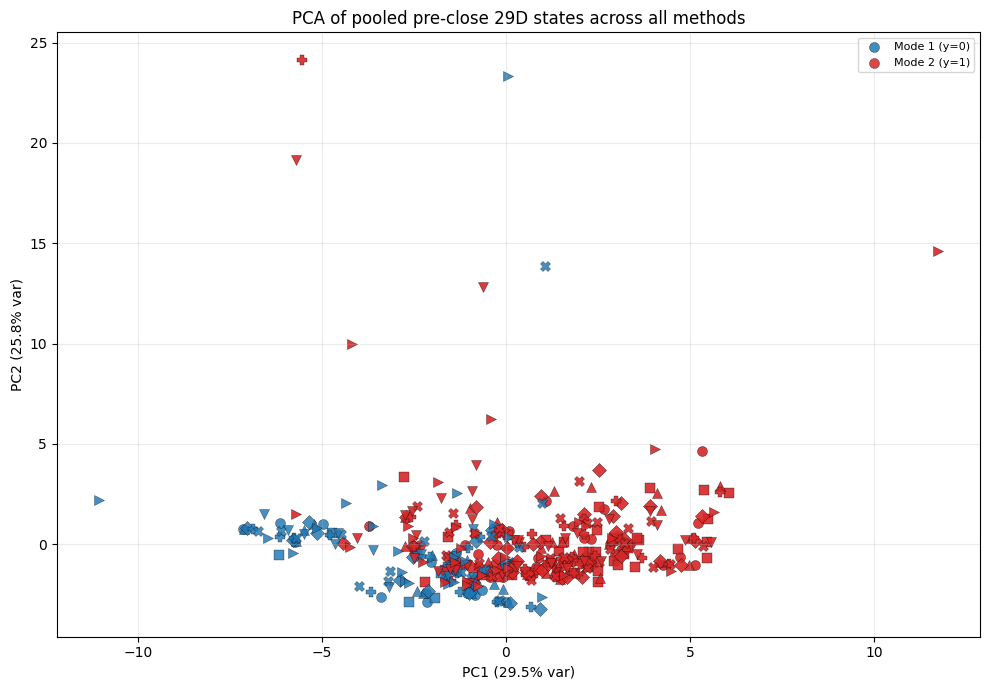


Top loading dimensions for PC1 (by absolute value):
  dim 07: loading=+0.3210
  dim 24: loading=+0.3208
  dim 04: loading=+0.3201
  dim 03: loading=-0.3164
  dim 22: loading=+0.3143
  dim 25: loading=+0.2891
  dim 06: loading=+0.2649
  dim 01: loading=+0.2274

Top loading dimensions for PC2 (by absolute value):
  dim 08: loading=+0.3121
  dim 23: loading=+0.2743
  dim 00: loading=+0.2690
  dim 09: loading=+0.2656
  dim 18: loading=-0.2609
  dim 15: loading=-0.2581
  dim 21: loading=-0.2501
  dim 20: loading=-0.2318


In [16]:
# PCA on all methods: DP Base, SNR, and guided variants pooled together.
# This reuses the same pre-close index rule, then asks whether mode 1 vs mode 2 separate better across methods.

import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

RUN_ROOT = Path("/scratch/gilbreth/zoellner/diffusion_rollouts/can_rollouts/comparison/20260407_210830_v1_s1_50")
ENV_NAME = "n16h300r60g1bYfYv1"
SEED_RANGE = range(1, 51)
THRESHOLD = 0.97
CORE_START_FRACTION = 0.00
CORE_END_FRACTION = 0.90
VIOLATION_STEPS_FOR_MODE2 = 3
NEG_EPS = 1e-5

def _read_rows(rows_path: Path):
    rows = []
    if not rows_path.exists():
        return rows
    with rows_path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def compute_gripper_distance(states: np.ndarray) -> np.ndarray:
    gripper_qpos = np.asarray(states[:, 27:29], dtype=np.float32)
    return np.linalg.norm(gripper_qpos, axis=1)


def find_pre_drop_index(states: np.ndarray) -> int | None:
    gripper_dist = compute_gripper_distance(states)
    n = len(gripper_dist)
    if n == 0:
        return None

    gradient = np.gradient(gripper_dist)
    start_idx = max(0, 10)
    end_idx = min(n, n - 10) if n > 20 else n
    if not (start_idx < end_idx):
        return None

    gradient_window = gradient[start_idx:end_idx]
    closure_idx = start_idx + int(np.argmin(gradient_window))

    final_pre_liftoff_idx = max(0, closure_idx - 1)
    diff = np.diff(gripper_dist)
    lookback = 40
    local_start = max(0, closure_idx - lookback)
    local_end = min(len(diff) - 1, closure_idx)
    dec_candidates = [t for t in range(local_start, local_end + 1) if diff[t] < -NEG_EPS]

    if dec_candidates:
        return int(dec_candidates[0])
    return int(final_pre_liftoff_idx)


def parse_method_order(method_slugs):
    def method_key(slug):
        if slug == "dp_base":
            return (0, 0)
        if slug == "snr_k8":
            return (1, 0)
        if slug.startswith("dp_guidance_l"):
            try:
                return (2, int(slug.split("l", 1)[1]))
            except Exception:
                return (2, 10_000)
        return (3, slug)
    return sorted(method_slugs, key=method_key)


rows_cache = {}
method_slugs = []
for method_dir in RUN_ROOT.iterdir():
    if not method_dir.is_dir():
        continue
    rows_path = method_dir / "rollout_rows.jsonl"
    if not rows_path.exists():
        continue
    method_slugs.append(method_dir.name)
    rows_cache[method_dir.name] = _read_rows(rows_path)

method_slugs = parse_method_order(method_slugs)
method_labels = {
    "dp_base": "DP Base",
    "snr_k8": "SNR (sample-and-rank)",
}
for slug in method_slugs:
    if slug.startswith("dp_guidance_l"):
        method_labels[slug] = f"Guided (λ={slug.split('l', 1)[1]})"
    else:
        method_labels.setdefault(slug, slug)

# Build pooled dataset from all methods.
X_rows = []
y = []
method_names = []
seed_names = []
pre_drop_by_method = {slug: 0 for slug in method_slugs}
mode_counts_by_method = {slug: {1: 0, 2: 0} for slug in method_slugs}

for method_slug in method_slugs:
    rows = rows_cache[method_slug]
    for row in rows:
        if str(row.get("init_name", "")) != ENV_NAME:
            continue
        seed = int(row.get("seed", -1))
        if seed not in SEED_RANGE:
            continue

        npz_path = RUN_ROOT / method_slug / f"{ENV_NAME}__seed_{seed:02d}" / "rollout_numeric.npz"
        if not npz_path.exists():
            continue

        data = np.load(npz_path)
        states = np.asarray(data["states"], dtype=np.float32)
        can_rzz = np.asarray(data["rzz_mujoco"], dtype=np.float32)

        n = len(can_rzz)
        i0 = max(0, min(n - 1, int(n * CORE_START_FRACTION)))
        i1 = min(n, max(i0 + 1, int(n * CORE_END_FRACTION)))
        can_rzz_core = can_rzz[i0:i1]
        violation_count = int(np.sum(can_rzz_core < THRESHOLD))
        mode = 2 if violation_count >= VIOLATION_STEPS_FOR_MODE2 else 1

        pre_drop_idx = find_pre_drop_index(states)
        if pre_drop_idx is None or pre_drop_idx >= len(states):
            continue

        X_rows.append(np.asarray(states[pre_drop_idx], dtype=np.float32))
        y.append(0 if mode == 1 else 1)
        method_names.append(method_slug)
        seed_names.append(seed)
        pre_drop_by_method[method_slug] += 1
        mode_counts_by_method[method_slug][mode] += 1

X = np.asarray(X_rows, dtype=np.float32)
y = np.asarray(y, dtype=np.int32)

print(f"Pooled X shape: {X.shape}")
print(f"Pooled y shape: {y.shape}")
print()
print("Per-method sample counts:")
for method_slug in method_slugs:
    print(
        f"  {method_labels[method_slug]:<22} N={pre_drop_by_method[method_slug]:>3} | "
        f"mode1={mode_counts_by_method[method_slug][1]:>3} mode2={mode_counts_by_method[method_slug][2]:>3}"
    )

if X.ndim != 2 or X.shape[1] != 29:
    raise RuntimeError(f"Expected X to have shape (N, 29), got {X.shape}")

# Standardize features before PCA.
mu = X.mean(axis=0, keepdims=True)
sigma = X.std(axis=0, keepdims=True)
sigma_safe = np.where(sigma < 1e-8, 1.0, sigma)
X_std = (X - mu) / sigma_safe

# PCA to 2D.
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_std)

print()
print("explained_variance_ratio_:", pca.explained_variance_ratio_)
print("cumulative explained variance (2 PCs):", float(np.sum(pca.explained_variance_ratio_)))

# Scatter plot colored by mode; marker shape tracks method family.
mode_colors = {0: "#1f77b4", 1: "#d62728"}
method_markers = ["o", "s", "^", "D", "P", "X", "v", ">", "<"]
method_to_marker = {slug: method_markers[i % len(method_markers)] for i, slug in enumerate(method_slugs)}

fig, ax = plt.subplots(figsize=(10, 7))

for method_slug in method_slugs:
    idxs = [i for i, m in enumerate(method_names) if m == method_slug]
    if not idxs:
        continue
    for mode in [0, 1]:
        mode_idxs = [i for i in idxs if y[i] == mode]
        if not mode_idxs:
            continue
        ax.scatter(
            X_pca[mode_idxs, 0],
            X_pca[mode_idxs, 1],
            s=52,
            alpha=0.82 if mode == 0 else 0.90,
            c=mode_colors[mode],
            marker=method_to_marker[method_slug],
            edgecolor="k",
            linewidth=0.25,
            label=f"{method_labels[method_slug]} | mode {mode + 1}" if len(idxs) <= 4 and mode == 0 else None,
        )

# Add compact legend entries for mode colors.
ax.scatter([], [], c=mode_colors[0], s=52, alpha=0.85, edgecolor="k", linewidth=0.25, label="Mode 1 (y=0)")
ax.scatter([], [], c=mode_colors[1], s=52, alpha=0.85, edgecolor="k", linewidth=0.25, label="Mode 2 (y=1)")

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var)")
ax.set_title("PCA of pooled pre-close 29D states across all methods")
ax.grid(alpha=0.25)
ax.legend(frameon=True, fontsize=8, loc="best")

plt.tight_layout()
plt.show()

# Inspect PCA loadings.
pc1 = pca.components_[0]
pc2 = pca.components_[1]

print()
print("Top loading dimensions for PC1 (by absolute value):")
for j in np.argsort(np.abs(pc1))[::-1][:8]:
    print(f"  dim {j:02d}: loading={pc1[j]:+.4f}")

print()
print("Top loading dimensions for PC2 (by absolute value):")
for j in np.argsort(np.abs(pc2))[::-1][:8]:
    print(f"  dim {j:02d}: loading={pc2[j]:+.4f}")

### Guiding based on EEF Rzz

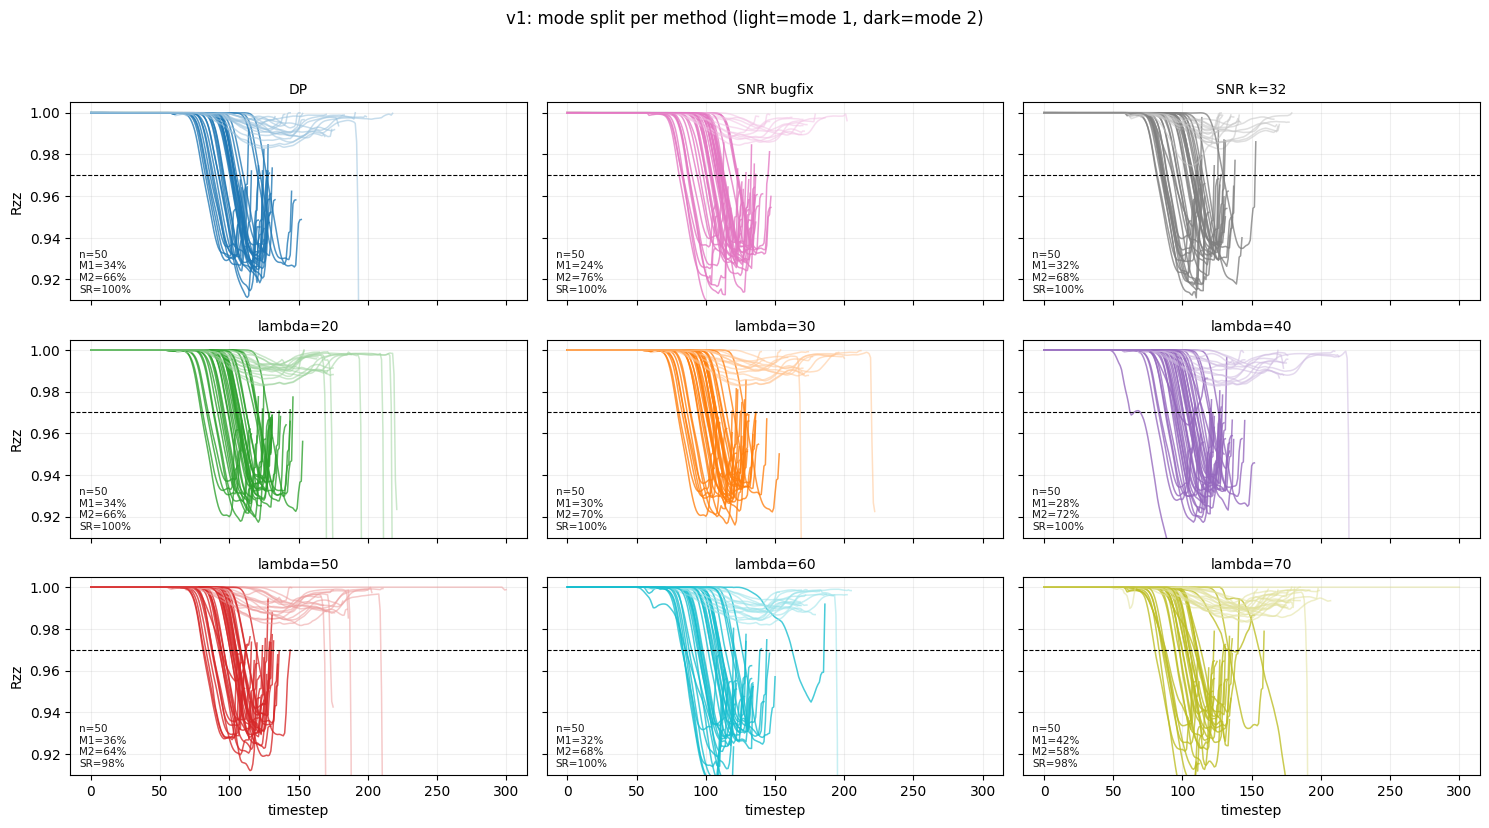

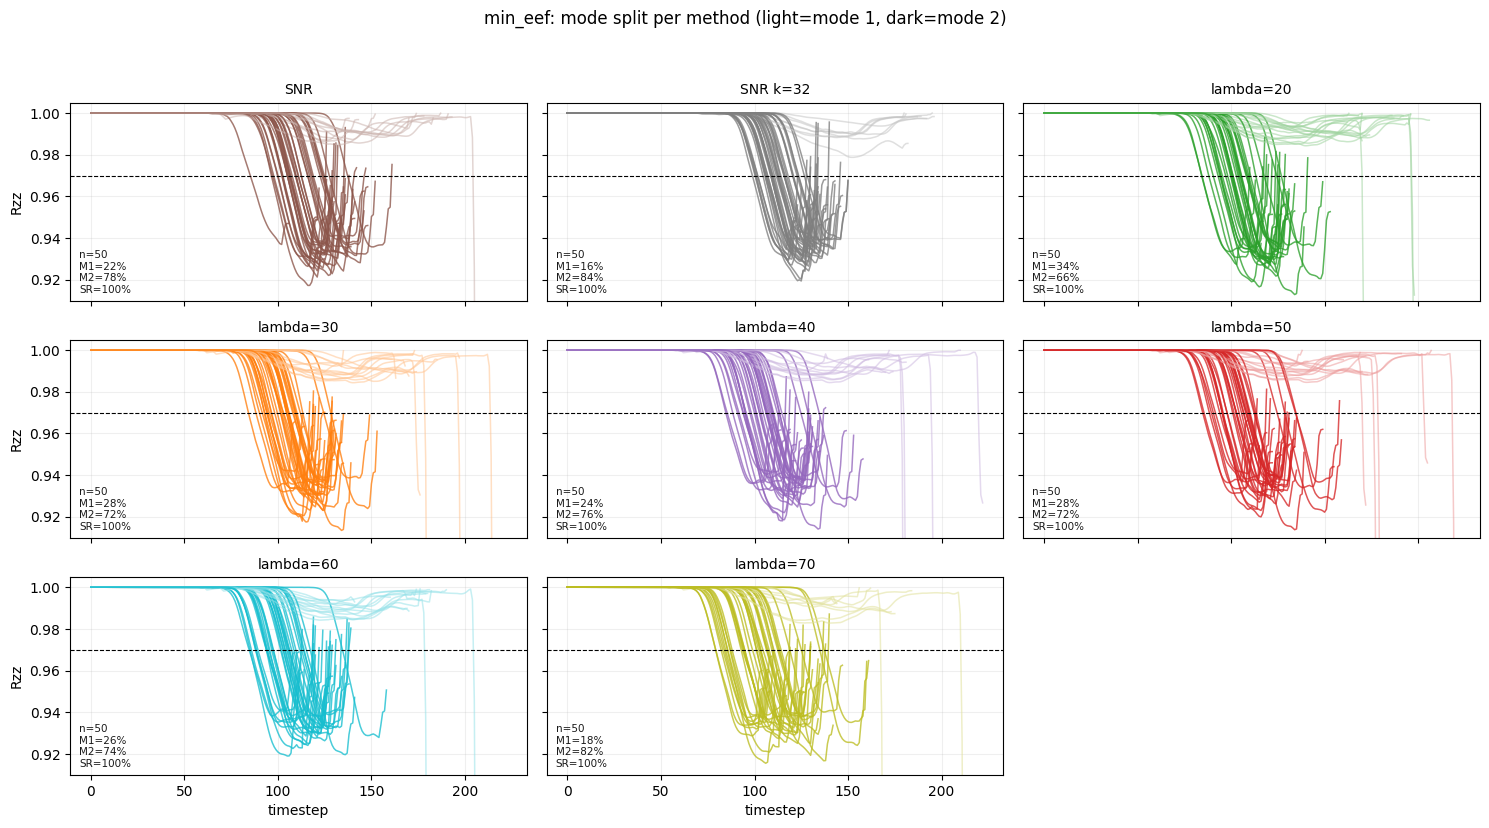

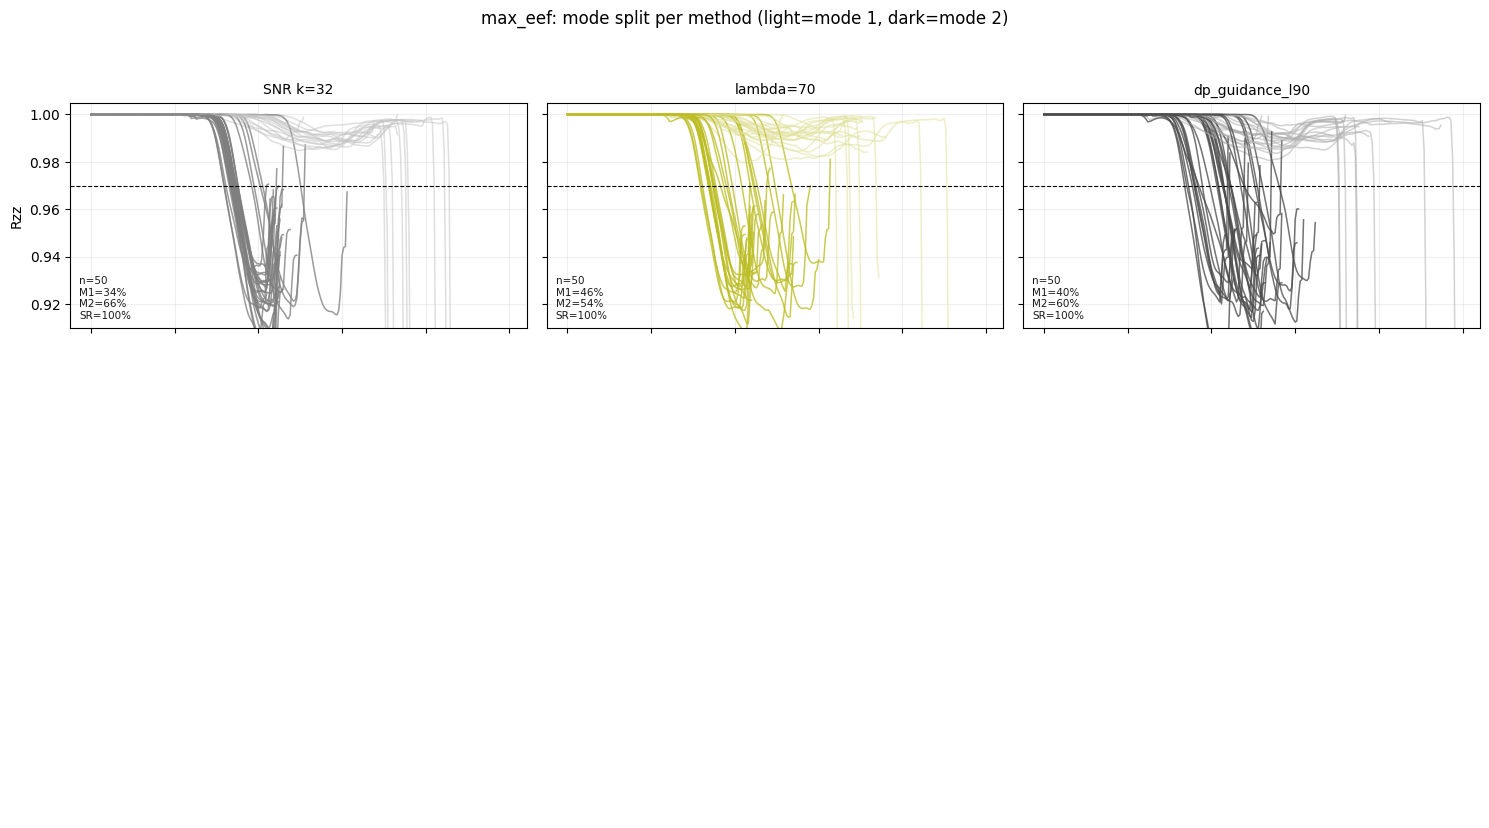

run roots:
  - v1: /scratch/gilbreth/zoellner/diffusion_rollouts/can_rollouts/comparison/20260407_210830_v1_s1_50
  - min_eef: /scratch/gilbreth/zoellner/diffusion_rollouts/can_rollouts/comparison/min_eef_rzz_guidance
  - max_eef: /scratch/gilbreth/zoellner/diffusion_rollouts/can_rollouts/comparison/max_eef_rzz_guidance
env: n16h300r60g1bYfYv1 | threshold: 0.97 | core window: [0.00, 0.90]
mode 2 trigger: >= 3 violations in core window

Run        Method                N   Mode1 %   Mode2 %  Success %       Avg_Rzz (core)      Avg_EEF_Rzz     Timestep_VFrac(core)      Avg_Rzz M1 (core)      Avg_Rzz M2 (core)
----------------------------------------------------------------------------------------------------------------------------------------------------------------------
v1         DP                   50    34.00%    66.00%    100.00%               0.9945          -0.9951                   0.0733                 0.9975                 0.9930
v1         SNR bugfix           50    24.00

In [ ]:
# Mode split per method across multiple runs: method-specific color family, light=mode 1, dark=mode 2.

from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors

base_dir = Path("/scratch/gilbreth/zoellner/diffusion_rollouts/can_rollouts/comparison")
env_name = "n16h300r60g1bYfYv1"
seed_range = range(1, 51)
threshold = 0.97
ymin, ymax = 0.91, 1.005

core_start_fraction = 0.00
core_end_fraction = 0.90
violation_steps_for_mode2 = 3

# Run order for plotting and table grouping.
run_roots = [
    ("v1_s1_50", base_dir / "20260407_210830_v1_s1_50"),
    ("min_eef_rzz_guidance", base_dir / "min_eef_rzz_guidance"),
    ("max_eef_rzz_guidance", base_dir / "max_eef_rzz_guidance"),
]

for run_tag, run_root in run_roots:
    if not run_root.exists():
        raise RuntimeError(f"Run directory not found: {run_root}")

method_labels = {
    "dp_base": "DP",
    "snr_k8": "SNR",
    "snr_k8_bugfix": "SNR bugfix",
    "snr_k32": "SNR k=32",
    "dp_guidance_l20": "lambda=20",
    "dp_guidance_l30": "lambda=30",
    "dp_guidance_l40": "lambda=40",
    "dp_guidance_l50": "lambda=50",
    "dp_guidance_l60": "lambda=60",
    "dp_guidance_l70": "lambda=70",
}

method_base_colors = {
    "dp_base": "#1f77b4",
    "snr_k8": "#8c564b",
    "snr_k8_bugfix": "#e377c2",
    "snr_k32": "#7f7f7f",
    "dp_guidance_l20": "#2ca02c",
    "dp_guidance_l30": "#ff7f0e",
    "dp_guidance_l40": "#9467bd",
    "dp_guidance_l50": "#d62728",
    "dp_guidance_l60": "#17becf",
    "dp_guidance_l70": "#bcbd22",
}

preferred_order = [
    "dp_base",
    "snr_k8",
    "snr_k8_bugfix",
    "snr_k32",
    "dp_guidance_l20",
    "dp_guidance_l30",
    "dp_guidance_l40",
    "dp_guidance_l50",
    "dp_guidance_l60",
    "dp_guidance_l70",
]

run_tag_label = {
    "v1_s1_50": "v1",
    "min_eef_rzz_guidance": "min_eef",
    "max_eef_rzz_guidance": "max_eef",
}


def lighten_color(color, amount=0.6):
    r, g, b = mcolors.to_rgb(color)
    return (1 - amount) + amount * r, (1 - amount) + amount * g, (1 - amount) + amount * b


def _rotation_6d_to_rzz_numpy(rot6d: np.ndarray) -> np.ndarray:
    rot6d = np.asarray(rot6d, dtype=np.float32)
    a1 = rot6d[:, 0:3]
    a2 = rot6d[:, 3:6]

    b1 = a1 / (np.linalg.norm(a1, axis=1, keepdims=True) + 1e-8)
    a2_proj = np.sum(b1 * a2, axis=1, keepdims=True) * b1
    b2_raw = a2 - a2_proj
    b2 = b2_raw / (np.linalg.norm(b2_raw, axis=1, keepdims=True) + 1e-8)
    b3 = np.cross(b1, b2)
    return b3[:, 2]


def _load_numeric_arrays(npz_path):
    data = np.load(npz_path)
    can_rzz = np.asarray(data["rzz_mujoco"], dtype=np.float32)
    states = np.asarray(data["states"], dtype=np.float32) if "states" in data.files else None
    return can_rzz, states


def _load_method_rollouts(run_root, method_slug):
    seed_to_rzz = {}
    seed_to_states = {}
    seed_to_success = {}

    rows_path = run_root / method_slug / "rollout_rows.jsonl"
    if rows_path.exists():
        with rows_path.open("r", encoding="utf-8") as f:
            rows = [json.loads(line) for line in f if line.strip()]

        for r in rows:
            if r.get("init_name") != env_name:
                continue
            seed = int(r.get("seed", -1))
            if seed not in seed_range:
                continue

            npz_path = run_root / method_slug / f"{env_name}__seed_{seed:02d}" / "rollout_numeric.npz"
            if not npz_path.exists():
                continue

            can_rzz, states = _load_numeric_arrays(npz_path)
            seed_to_rzz[seed] = can_rzz
            if states is not None:
                seed_to_states[seed] = states
            seed_to_success[seed] = float(bool(r.get("success", False)))

    # Always backfill from directory layout, even if rollout_rows.jsonl exists.
    for seed in seed_range:
        if seed in seed_to_rzz:
            continue

        candidate_dirs = [
            run_root / method_slug / f"{env_name}__seed_{seed:02d}",
            run_root / method_slug / f"{env_name}__seed_{seed}",
            run_root / method_slug / f"{env_name}_seed{seed}",
            run_root / method_slug / f"{env_name}_seed_{seed:02d}",
        ]
        rollout_dir = next((d for d in candidate_dirs if d.exists()), None)
        if rollout_dir is None:
            continue

        npz_path = rollout_dir / "rollout_numeric.npz"
        if not npz_path.exists():
            continue

        can_rzz, states = _load_numeric_arrays(npz_path)
        seed_to_rzz[seed] = can_rzz
        if states is not None:
            seed_to_states[seed] = states

        stats_path = rollout_dir / "rollout_stats.json"
        if seed not in seed_to_success and stats_path.exists():
            with stats_path.open("r", encoding="utf-8") as f:
                stats = json.load(f)
            seed_to_success[seed] = float(bool(stats.get("success", False)))

    return seed_to_rzz, seed_to_states, seed_to_success


summary_rows = []

for run_idx, (run_tag, run_root) in enumerate(run_roots):
    methods = [p.name for p in sorted(run_root.iterdir()) if p.is_dir()]
    methods = [m for m in preferred_order if m in methods] + [m for m in methods if m not in preferred_order]

    # Drop the bugged SNR from v1 only.
    if run_tag == "v1_s1_50":
        methods = [m for m in methods if m != "snr_k8"]

    if len(methods) > 9:
        print(f"[{run_tag_label.get(run_tag, run_tag)}] showing first 9 methods out of {len(methods)}")
        methods_plot = methods[:9]
    else:
        methods_plot = methods

    nrows, ncols = 3, 3
    fig, axes = plt.subplots(nrows, ncols, figsize=(15.0, 8.4), sharex=True, sharey=True)
    axes = np.array(axes).reshape(-1)

    for ax, method_slug in zip(axes, methods_plot):
        seed_to_rzz, seed_to_states, seed_to_success = _load_method_rollouts(run_root, method_slug)

        seed_to_mode = {}
        per_rollout_core_mean_rzz = []
        per_rollout_core_mean_eef_rzz = []
        per_rollout_core_timestep_vfrac = []
        per_mode_core_mean_rzz = {1: [], 2: []}

        for seed, rzz in seed_to_rzz.items():
            n = len(rzz)
            i0 = max(0, min(n - 1, int(n * core_start_fraction)))
            i1 = min(n, max(i0 + 1, int(n * core_end_fraction)))
            rzz_core = rzz[i0:i1]

            violation_count = int(np.sum(rzz_core < threshold))
            seed_to_mode[seed] = 2 if violation_count >= violation_steps_for_mode2 else 1

            core_mean_rzz = float(np.mean(rzz_core))
            per_rollout_core_mean_rzz.append(core_mean_rzz)
            per_rollout_core_timestep_vfrac.append(float(np.mean(rzz_core < threshold)))
            per_mode_core_mean_rzz[seed_to_mode[seed]].append(core_mean_rzz)

            states = seed_to_states.get(seed)
            if states is not None and states.ndim == 2 and states.shape[1] >= 27 and len(states) > 0:
                eef_rot6d = states[:, 21:27]
                eef_rzz = _rotation_6d_to_rzz_numpy(eef_rot6d)
                n_eef = len(eef_rzz)
                j0 = max(0, min(n_eef - 1, int(n_eef * core_start_fraction)))
                j1 = min(n_eef, max(j0 + 1, int(n_eef * core_end_fraction)))
                per_rollout_core_mean_eef_rzz.append(float(np.mean(eef_rzz[j0:j1])))

        base_color = method_base_colors.get(method_slug, "#4c4c4c")
        light_color = lighten_color(base_color, amount=0.45)
        dark_color = mcolors.to_rgb(base_color)

        for seed in seed_range:
            rzz = seed_to_rzz.get(seed)
            if rzz is None:
                continue

            mode = seed_to_mode[seed]
            color = light_color if mode == 1 else dark_color
            alpha = 0.55 if mode == 1 else 0.78
            ax.plot(rzz, color=color, lw=1.1, alpha=alpha)

        ax.axhline(threshold, color="black", linestyle="--", linewidth=0.8)
        ax.set_title(method_labels.get(method_slug, method_slug), fontsize=10)
        ax.grid(alpha=0.2)
        ax.set_ylim(ymin, ymax)

        total = len(seed_to_rzz)
        mode1_count = sum(1 for s in seed_to_rzz if seed_to_mode.get(s) == 1)
        mode2_count = sum(1 for s in seed_to_rzz if seed_to_mode.get(s) == 2)
        mode1_pct = (100.0 * mode1_count / total) if total else float("nan")
        mode2_pct = (100.0 * mode2_count / total) if total else float("nan")
        success_vals = [seed_to_success[s] for s in seed_to_rzz if s in seed_to_success]
        success_pct = (100.0 * float(np.mean(success_vals))) if success_vals else float("nan")

        avg_rzz_core = float(np.mean(per_rollout_core_mean_rzz)) if per_rollout_core_mean_rzz else float("nan")
        avg_eef_rzz_core = (
            float(np.mean(per_rollout_core_mean_eef_rzz))
            if per_rollout_core_mean_eef_rzz
            else float("nan")
        )
        timestep_vfrac_core = float(np.mean(per_rollout_core_timestep_vfrac)) if per_rollout_core_timestep_vfrac else float("nan")
        avg_rzz_mode1 = float(np.mean(per_mode_core_mean_rzz[1])) if per_mode_core_mean_rzz[1] else float("nan")
        avg_rzz_mode2 = float(np.mean(per_mode_core_mean_rzz[2])) if per_mode_core_mean_rzz[2] else float("nan")

        summary_rows.append(
            {
                "run_idx": run_idx,
                "run_tag": run_tag,
                "method_slug": method_slug,
                "label": method_labels.get(method_slug, method_slug),
                "N": total,
                "mode1_pct": mode1_pct,
                "mode2_pct": mode2_pct,
                "success_pct": success_pct,
                "avg_rzz_core": avg_rzz_core,
                "avg_eef_rzz_core": avg_eef_rzz_core,
                "avg_rzz_mode1": avg_rzz_mode1,
                "avg_rzz_mode2": avg_rzz_mode2,
                "timestep_vfrac_core": timestep_vfrac_core,
            }
        )

        ax.text(
            0.02,
            0.04,
            f"n={total}\nM1={mode1_pct:.0f}%\nM2={mode2_pct:.0f}%\nSR={success_pct:.0f}%",
            transform=ax.transAxes,
            fontsize=7.5,
            alpha=0.9,
        )

    for ax in axes[len(methods_plot):]:
        ax.axis("off")

    for r in range(nrows):
        axes[r * ncols].set_ylabel("Rzz")
    for c in range(ncols):
        idx = (nrows - 1) * ncols + c
        axes[idx].set_xlabel("timestep")

    run_name = run_tag_label.get(run_tag, run_tag)
    fig.suptitle(f"{run_name}: mode split per method (light=mode 1, dark=mode 2)", fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

print("run roots:")
for run_tag, run_root in run_roots:
    print(f"  - {run_tag_label.get(run_tag, run_tag)}: {run_root}")
print(f"env: {env_name} | threshold: {threshold:.2f} | core window: [{core_start_fraction:.2f}, {core_end_fraction:.2f}]")
print(f"mode 2 trigger: >= {violation_steps_for_mode2} violations in core window")
print()

base_row = next((r for r in summary_rows if r["run_tag"] == "v1_s1_50" and r["method_slug"] == "dp_base"), None)
if base_row is None:
    print("No v1 DP base found; showing absolute metrics (no deltas).")

base_avg_rzz = base_row["avg_rzz_core"] if base_row is not None else None
base_avg_eef_rzz = base_row["avg_eef_rzz_core"] if base_row is not None else None
base_rzz_mode1 = base_row["avg_rzz_mode1"] if base_row is not None else None
base_rzz_mode2 = base_row["avg_rzz_mode2"] if base_row is not None else None
base_tvf = base_row["timestep_vfrac_core"] if base_row is not None else None

print(
    f"{'Run':<10} {'Method':<18} {'N':>4} {'Mode1 %':>9} {'Mode2 %':>9} {'Success %':>10} {'Avg_Rzz (core)':>20} {'Avg_EEF_Rzz':>16} {'Timestep_VFrac(core)':>24} {'Avg_Rzz M1 (core)':>22} {'Avg_Rzz M2 (core)':>22}"
)
print("-" * 166)

prev_run = None
for row in summary_rows:
    if prev_run is not None and row["run_tag"] != prev_run:
        print("-" * 166)
    prev_run = row["run_tag"]

    run_col = run_tag_label.get(row["run_tag"], row["run_tag"])
    label = row["label"]
    n = row["N"]
    m1 = row["mode1_pct"]
    m2 = row["mode2_pct"]
    sr = row["success_pct"]
    avg_rzz = row["avg_rzz_core"]
    avg_eef_rzz = row["avg_eef_rzz_core"]
    avg_rzz_mode1 = row["avg_rzz_mode1"]
    avg_rzz_mode2 = row["avg_rzz_mode2"]
    tvf = row["timestep_vfrac_core"]

    is_base = base_row is not None and row["run_tag"] == "v1_s1_50" and row["method_slug"] == "dp_base"

    if base_row is None or is_base:
        avg_rzz_col = f"{avg_rzz:.4f}"
        avg_eef_rzz_col = f"{avg_eef_rzz:.4f}" if np.isfinite(avg_eef_rzz) else "nan"
        tvf_col = f"{tvf:.4f}"
        avg_rzz_mode1_col = f"{avg_rzz_mode1:.4f}"
        avg_rzz_mode2_col = f"{avg_rzz_mode2:.4f}"
    else:
        delta_rzz = avg_rzz - base_avg_rzz
        delta_rzz_mode1 = avg_rzz_mode1 - base_rzz_mode1
        delta_rzz_mode2 = avg_rzz_mode2 - base_rzz_mode2
        delta_tvf = tvf - base_tvf
        avg_rzz_col = f"{delta_rzz:+.4f} ({avg_rzz:.4f})"
        if np.isfinite(avg_eef_rzz) and np.isfinite(base_avg_eef_rzz):
            delta_eef_rzz = avg_eef_rzz - base_avg_eef_rzz
            avg_eef_rzz_col = f"{delta_eef_rzz:+.4f} ({avg_eef_rzz:.4f})"
        else:
            avg_eef_rzz_col = "nan"
        tvf_col = f"{delta_tvf:+.4f} ({tvf:.4f})"
        avg_rzz_mode1_col = f"{delta_rzz_mode1:+.4f} ({avg_rzz_mode1:.4f})"
        avg_rzz_mode2_col = f"{delta_rzz_mode2:+.4f} ({avg_rzz_mode2:.4f})"

    print(
        f"{run_col:<10} {label:<18} {n:>4} {m1:>8.2f}% {m2:>8.2f}% {sr:>9.2f}% {avg_rzz_col:>20} {avg_eef_rzz_col:>16} {tvf_col:>24} {avg_rzz_mode1_col:>22} {avg_rzz_mode2_col:>22}"
    )

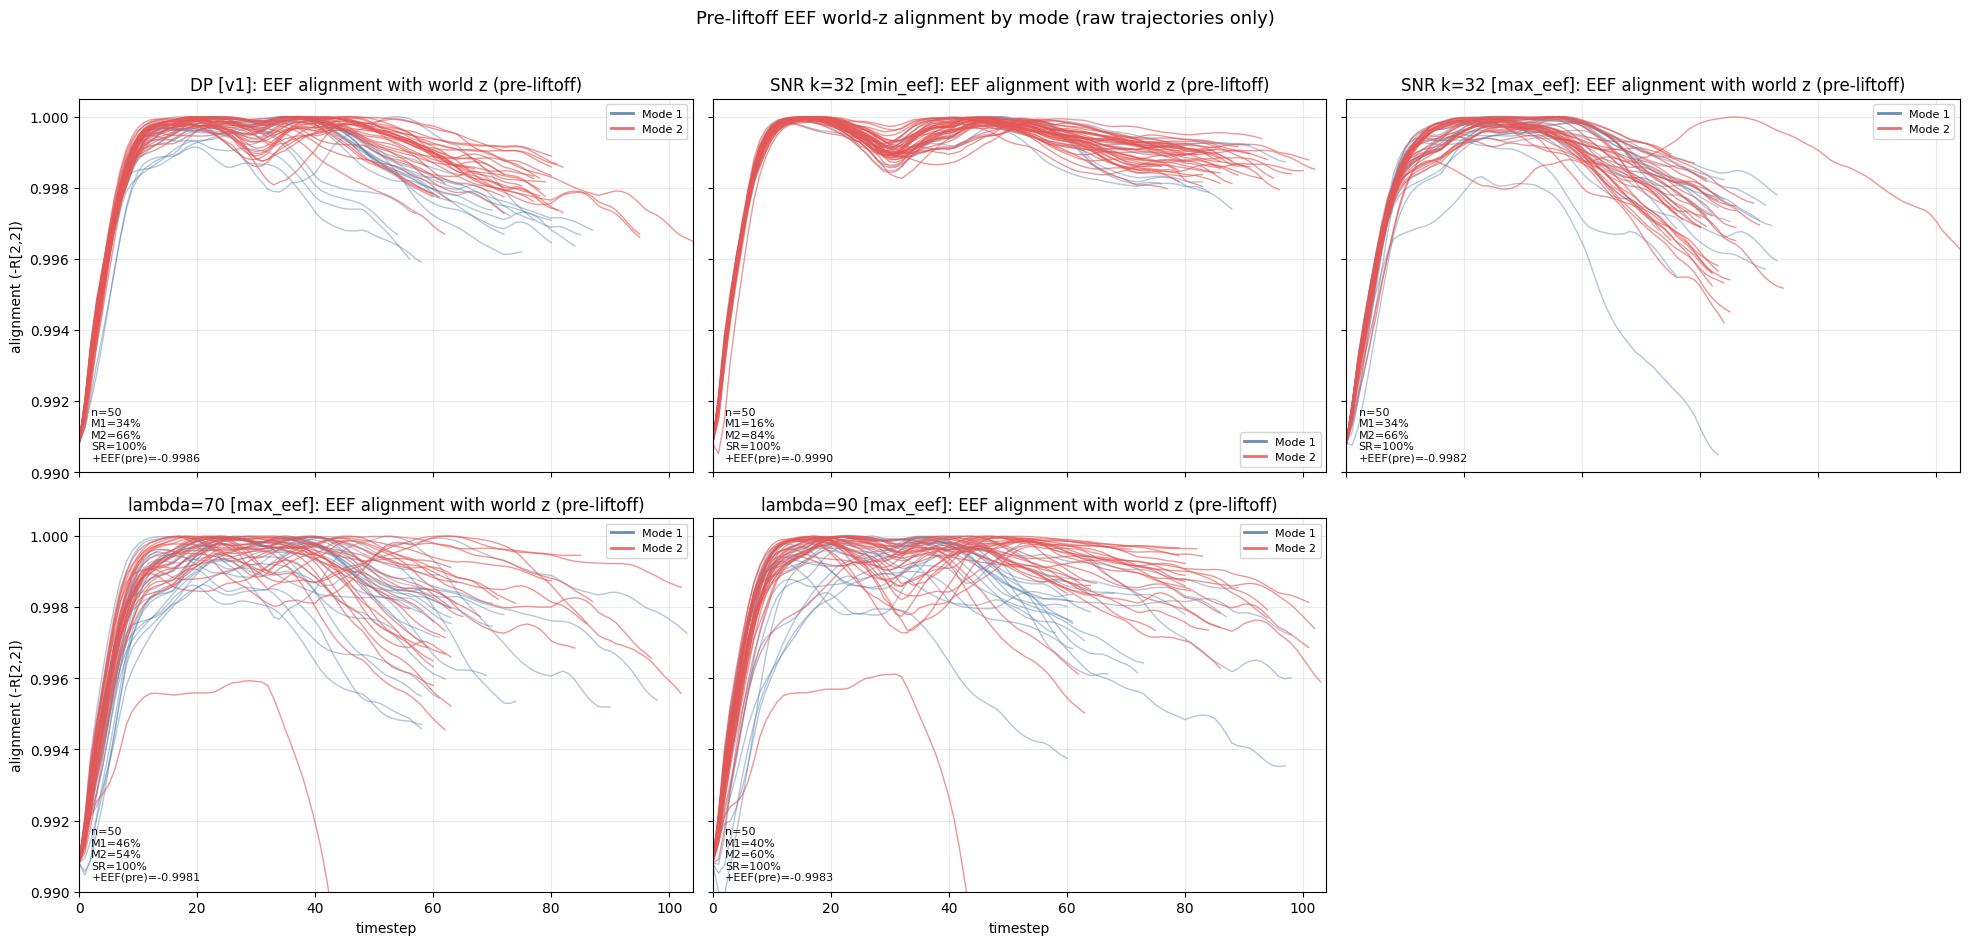

env: n16h300r60g1bYfYv1 | threshold: 0.97 | core window: [0.00, 0.90]
mode 2 trigger: >= 3 can-Rzz violations in core window
shared xlim: (0, 104) | shared ylim: (0.9900, 1.0005)

DP         [v1] | N=50 | M1=17 | M2=33 | SR=100.0% | closure mean= 74.34 std=10.75 | +EEF(pre)=-0.998613 | +EEF(core)=-0.995059
SNR k=32   [min_eef] | N=50 | M1= 8 | M2=42 | SR=100.0% | closure mean= 86.56 std= 7.42 | +EEF(pre)=-0.998975 | +EEF(core)=-0.995928
SNR k=32   [max_eef] | N=50 | M1=17 | M2=33 | SR=100.0% | closure mean= 64.88 std= 7.68 | +EEF(pre)=-0.998191 | +EEF(core)=-0.993223
lambda=70  [max_eef] | N=50 | M1=23 | M2=27 | SR=100.0% | closure mean= 70.34 std=13.38 | +EEF(pre)=-0.998111 | +EEF(core)=-0.994840
lambda=90  [max_eef] | N=50 | M1=20 | M2=30 | SR=100.0% | closure mean= 77.20 std=13.91 | +EEF(pre)=-0.998340 | +EEF(core)=-0.995396

Average +EEF_Rzz objective (lower is better)
Method             Run               Pre-liftoff (+EEF, delta)      Full core (+EEF, delta)
----------------------

In [ ]:
# Pre-liftoff EEF world-z alignment: DP (v1), SNR k=32 (min_eef / max_eef), and +EEF guided lambdas from max_eef.

from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

base_dir = Path("/scratch/gilbreth/zoellner/diffusion_rollouts/can_rollouts/comparison")
env_name = "n16h300r60g1bYfYv1"
seed_range = range(1, 51)

threshold = 0.97
core_start_fraction = 0.00
core_end_fraction = 0.90
violation_steps_for_mode2 = 3

method_specs = [
    {
        "method_slug": "dp_base",
        "label": "DP",
        "run_root": base_dir / "20260407_210830_v1_s1_50",
        "run_tag": "v1",
    },
    {
        "method_slug": "snr_k32",
        "label": "SNR k=32",
        "run_root": base_dir / "min_eef_rzz_guidance",
        "run_tag": "min_eef",
    },
    {
        "method_slug": "snr_k32",
        "label": "SNR k=32",
        "run_root": base_dir / "max_eef_rzz_guidance",
        "run_tag": "max_eef",
    },
    {
        "method_slug": "dp_guidance_l70",
        "label": "lambda=70",
        "run_root": base_dir / "max_eef_rzz_guidance",
        "run_tag": "max_eef",
    },
    {
        "method_slug": "dp_guidance_l90",
        "label": "lambda=90",
        "run_root": base_dir / "max_eef_rzz_guidance",
        "run_tag": "max_eef",
    },
]

mode_colors = {
    1: "#4C78A8",
    2: "#E45756",
}

for spec in method_specs:
    if not spec["run_root"].exists():
        raise FileNotFoundError(f"Missing run root: {spec['run_root']}")


def reconstruct_rotation_matrix_from_6d(q6d: np.ndarray) -> np.ndarray:
    q6d = np.asarray(q6d, dtype=np.float32)
    a1 = q6d[:3]
    a2 = q6d[3:6]

    b1 = a1 / (np.linalg.norm(a1) + 1e-8)
    a2_proj = np.dot(b1, a2) * b1
    b2_raw = a2 - a2_proj
    b2 = b2_raw / (np.linalg.norm(b2_raw) + 1e-8)
    b3 = np.cross(b1, b2)
    return np.stack([b1, b2, b3], axis=1)


def _load_rollout_row_index(rows_path: Path):
    seed_to_success = {}
    if not rows_path.exists():
        return seed_to_success
    with rows_path.open("r", encoding="utf-8") as f:
        rows = [json.loads(line) for line in f if line.strip()]
    for r in rows:
        if r.get("init_name") != env_name:
            continue
        seed = int(r.get("seed", -1))
        if seed in seed_range:
            seed_to_success[seed] = float(bool(r.get("success", False)))
    return seed_to_success


def _load_method_data(run_root: Path, method_slug: str):
    method_root = run_root / method_slug
    if not method_root.exists():
        raise FileNotFoundError(f"Missing method directory: {method_root}")

    seed_to_states = {}
    seed_to_can_rzz = {}
    seed_to_success = _load_rollout_row_index(method_root / "rollout_rows.jsonl")

    for seed in seed_range:
        candidate_dirs = [
            method_root / f"{env_name}__seed_{seed:02d}",
            method_root / f"{env_name}__seed_{seed}",
            method_root / f"{env_name}_seed{seed}",
            method_root / f"{env_name}_seed_{seed:02d}",
        ]
        rollout_dir = next((d for d in candidate_dirs if d.exists()), None)
        if rollout_dir is None:
            continue

        npz_path = rollout_dir / "rollout_numeric.npz"
        if not npz_path.exists():
            continue

        data = np.load(npz_path)
        if "states" not in data.files or "rzz_mujoco" not in data.files:
            continue

        seed_to_states[seed] = np.asarray(data["states"], dtype=np.float32)
        seed_to_can_rzz[seed] = np.asarray(data["rzz_mujoco"], dtype=np.float32)

        stats_path = rollout_dir / "rollout_stats.json"
        if seed not in seed_to_success and stats_path.exists():
            with stats_path.open("r", encoding="utf-8") as f:
                stats = json.load(f)
            seed_to_success[seed] = float(bool(stats.get("success", False)))

    return seed_to_states, seed_to_can_rzz, seed_to_success


def _closure_timestep(states: np.ndarray) -> int:
    gripper_qpos = np.asarray(states[:, 27:29], dtype=np.float32)
    gripper_dist = np.linalg.norm(gripper_qpos, axis=1)
    gradient = np.gradient(gripper_dist)

    n = len(gripper_dist)
    start_idx = 10
    end_idx = n - 10 if n > 20 else n
    if start_idx >= end_idx:
        return n

    local_idx = int(np.argmin(gradient[start_idx:end_idx]))
    return start_idx + local_idx


def _mode_from_can_rzz(can_rzz: np.ndarray) -> int:
    n = len(can_rzz)
    i0 = max(0, min(n - 1, int(n * core_start_fraction)))
    i1 = min(n, max(i0 + 1, int(n * core_end_fraction)))
    can_rzz_core = can_rzz[i0:i1]
    violation_count = int(np.sum(can_rzz_core < threshold))
    return 2 if violation_count >= violation_steps_for_mode2 else 1


method_results = {}
global_xmax = 1
global_ymin = np.inf
global_ymax = -np.inf

for spec in method_specs:
    method_slug = spec["method_slug"]
    run_root = spec["run_root"]

    seed_to_states, seed_to_can_rzz, seed_to_success = _load_method_data(run_root, method_slug)

    series_by_mode = {1: [], 2: []}
    closure_idxs = []
    mode_counts = {1: 0, 2: 0}
    success_vals = []
    plus_eef_rzz_scores_pre = []
    plus_eef_rzz_scores_core = []

    for seed in seed_range:
        states = seed_to_states.get(seed)
        can_rzz = seed_to_can_rzz.get(seed)
        if states is None or can_rzz is None or states.ndim != 2 or states.shape[1] < 29:
            continue

        closure_idx = _closure_timestep(states)
        closure_idxs.append(closure_idx)

        mode = _mode_from_can_rzz(can_rzz)
        mode_counts[mode] += 1

        if seed in seed_to_success:
            success_vals.append(seed_to_success[seed])

        eef_q6d_full = np.asarray(states[:, 21:27], dtype=np.float32)
        align_z_full = np.empty((len(eef_q6d_full),), dtype=np.float32)
        for i, q6d in enumerate(eef_q6d_full):
            R = reconstruct_rotation_matrix_from_6d(q6d)
            align_z_full[i] = -R[2, 2]

        # +EEF_Rzz objective uses eef_rzz = -alignment_z.
        eef_rzz_full = -align_z_full

        n_full = len(eef_rzz_full)
        k0 = max(0, min(n_full - 1, int(n_full * core_start_fraction)))
        k1 = min(n_full, max(k0 + 1, int(n_full * core_end_fraction)))
        eef_rzz_core = eef_rzz_full[k0:k1]

        align_z_pre = align_z_full[:closure_idx]
        if len(align_z_pre) > 0:
            series_by_mode[mode].append(align_z_pre)
            global_xmax = max(global_xmax, len(align_z_pre) - 1)
            global_ymin = min(global_ymin, float(np.min(align_z_pre)))
            global_ymax = max(global_ymax, float(np.max(align_z_pre)))
            eef_rzz_pre = -align_z_pre
            plus_eef_rzz_scores_pre.append(float(np.mean(eef_rzz_pre)))

        if len(eef_rzz_core) > 0:
            plus_eef_rzz_scores_core.append(float(np.mean(eef_rzz_core)))

    method_results[(spec["run_tag"], method_slug)] = {
        "label": spec["label"],
        "run_tag": spec["run_tag"],
        "run_root": run_root,
        "series_by_mode": series_by_mode,
        "mode_counts": mode_counts,
        "closure_idxs": closure_idxs,
        "success_vals": success_vals,
        "plus_eef_rzz_scores_pre": plus_eef_rzz_scores_pre,
        "plus_eef_rzz_scores_core": plus_eef_rzz_scores_core,
    }

if not np.isfinite(global_ymin) or not np.isfinite(global_ymax):
    raise RuntimeError("No pre-liftoff alignment data found.")

# Shared axis limits across all subplots.
shared_xlim = (0, global_xmax)
shared_ylim = (0.9900, 1.0005)

# Use a compact grid (instead of one long row) so panels are larger.
n_methods = len(method_specs)
ncols = 3
nrows = int(np.ceil(n_methods / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6.6 * ncols, 4.8 * nrows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).reshape(-1)

for ax, spec in zip(axes[:n_methods], method_specs):
    key = (spec["run_tag"], spec["method_slug"])
    result = method_results[key]
    series_by_mode = result["series_by_mode"]

    for mode in [1, 2]:
        color = mode_colors[mode]
        alpha = 0.42 if mode == 1 else 0.62
        for s in series_by_mode[mode]:
            ax.plot(s, color=color, lw=1.0, alpha=alpha)

    m1 = result["mode_counts"][1]
    m2 = result["mode_counts"][2]
    total = m1 + m2
    sr = 100.0 * float(np.mean(result["success_vals"])) if result["success_vals"] else float("nan")
    m1_pct = 100.0 * m1 / total if total else float("nan")
    m2_pct = 100.0 * m2 / total if total else float("nan")

    pre_vals = result["plus_eef_rzz_scores_pre"]
    obj_pre = float(np.mean(pre_vals)) if pre_vals else float("nan")

    ax.text(
        0.02,
        0.03,
        f"n={total}\nM1={m1_pct:.0f}%\nM2={m2_pct:.0f}%\nSR={sr:.0f}%\n+EEF(pre)={obj_pre:.4f}",
        transform=ax.transAxes,
        fontsize=8,
        alpha=0.95,
    )

    ax.plot([], [], color=mode_colors[1], lw=2.0, alpha=0.85, label="Mode 1")
    ax.plot([], [], color=mode_colors[2], lw=2.0, alpha=0.85, label="Mode 2")

    ax.set_title(f"{result['label']} [{result['run_tag']}]: EEF alignment with world z (pre-liftoff)")
    ax.set_xlim(*shared_xlim)
    ax.set_ylim(*shared_ylim)
    ax.grid(alpha=0.25)
    ax.legend(frameon=True, fontsize=8, loc="best")

for idx, ax in enumerate(axes[:n_methods]):
    row = idx // ncols
    col = idx % ncols
    if col == 0:
        ax.set_ylabel("alignment (-R[2,2])")
    if row == (nrows - 1):
        ax.set_xlabel("timestep")

for ax in axes[n_methods:]:
    ax.axis("off")

fig.suptitle("Pre-liftoff EEF world-z alignment by mode (raw trajectories only)", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print(f"env: {env_name} | threshold: {threshold:.2f} | core window: [{core_start_fraction:.2f}, {core_end_fraction:.2f}]")
print(f"mode 2 trigger: >= {violation_steps_for_mode2} can-Rzz violations in core window")
print(f"shared xlim: {shared_xlim} | shared ylim: ({shared_ylim[0]:.4f}, {shared_ylim[1]:.4f})")
print()

for spec in method_specs:
    key = (spec["run_tag"], spec["method_slug"])
    result = method_results[key]
    m1 = result["mode_counts"][1]
    m2 = result["mode_counts"][2]
    total = m1 + m2
    sr = 100.0 * float(np.mean(result["success_vals"])) if result["success_vals"] else float("nan")
    closure_idxs = result["closure_idxs"]
    closure_mean = float(np.mean(closure_idxs)) if closure_idxs else float("nan")
    closure_std = float(np.std(closure_idxs)) if closure_idxs else float("nan")
    pre_vals = result["plus_eef_rzz_scores_pre"]
    core_vals = result["plus_eef_rzz_scores_core"]
    obj_pre = float(np.mean(pre_vals)) if pre_vals else float("nan")
    obj_core = float(np.mean(core_vals)) if core_vals else float("nan")
    print(
        f"{result['label']:<10} [{result['run_tag']}] | N={total:>2} | M1={m1:>2} | M2={m2:>2} | SR={sr:>5.1f}% | "
        f"closure mean={closure_mean:>6.2f} std={closure_std:>5.2f} | +EEF(pre)={obj_pre:>8.6f} | +EEF(core)={obj_core:>8.6f}"
    )

print()
print("Average +EEF_Rzz objective (lower is better)")
print(
    f"{'Method':<18} {'Run':<10} {'Pre-liftoff (+EEF, delta)':>32} {'Full core (+EEF, delta)':>28}"
)
print("-" * 96)

base_key = ("v1", "dp_base")
base_result = method_results.get(base_key)
base_pre = float(np.mean(base_result["plus_eef_rzz_scores_pre"])) if base_result and base_result["plus_eef_rzz_scores_pre"] else float("nan")
base_core = float(np.mean(base_result["plus_eef_rzz_scores_core"])) if base_result and base_result["plus_eef_rzz_scores_core"] else float("nan")

for spec in method_specs:
    key = (spec["run_tag"], spec["method_slug"])
    result = method_results[key]
    pre_vals = result["plus_eef_rzz_scores_pre"]
    core_vals = result["plus_eef_rzz_scores_core"]
    pre_avg = float(np.mean(pre_vals)) if pre_vals else float("nan")
    core_avg = float(np.mean(core_vals)) if core_vals else float("nan")

    is_base = key == base_key
    if is_base or not (np.isfinite(base_pre) and np.isfinite(base_core)):
        pre_col = f"{pre_avg:>10.6f}"
        core_col = f"{core_avg:>10.6f}"
    else:
        pre_delta = pre_avg - base_pre
        core_delta = core_avg - base_core
        pre_col = f"{pre_delta:+.6f} ({pre_avg:.6f})"
        core_col = f"{core_delta:+.6f} ({core_avg:.6f})"

    print(f"{result['label']:<18} {result['run_tag']:<10} {pre_col:>32} {core_col:>28}")